In [3]:
# ============================================================
# 1. Imports and Global Configuration
# ============================================================

import sys
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Prophet
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print(sys.executable)

c:\Users\ajha26\Python310\python.exe


In [4]:
# ============================================================
# 2. Data Loading
# ============================================================

univariate_city_path = r"C:\Users\ajha26\Desktop\Research\Code\Statistical Time Series\Miami_and_Hialeah_alltraps.xlsx"

df_city = pd.read_excel(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-01-05,2,E5,Miami
1,2016-01-05,3,E1,Miami
2,2016-01-12,2,KB1,Miami
3,2016-01-12,1,E2,Miami
4,2016-01-12,6,VK1,Miami


In [5]:
# ============================================================
# 3. Hialeah Weekly Time Series
# ============================================================

df_hialeah = df_city[df_city["City"] == "Hialeah"].copy()

def weekly_aggregate(df, date_col, value_col):
    """
    Aggregates mosquito counts to weekly frequency.
    Missing weeks are filled with zero because no recorded mosquitoes
    should represent zero observed count for that week.
    """
    ts = (
        df.set_index(date_col)
        .resample("W")[value_col]
        .sum()
        .to_frame(name="mosquito_count")
    )
    
    ts["mosquito_count"] = ts["mosquito_count"].fillna(0)
    return ts

ts_hialeah = weekly_aggregate(
    df_hialeah,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

print("Hialeah weekly series shape:", ts_hialeah.shape)
ts_hialeah.head()

Hialeah weekly series shape: (273, 1)


,mosquito_count
Date_Submitted,
2016-08-21,1
2016-08-28,6
2016-09-04,1
2016-09-11,17
2016-09-18,46


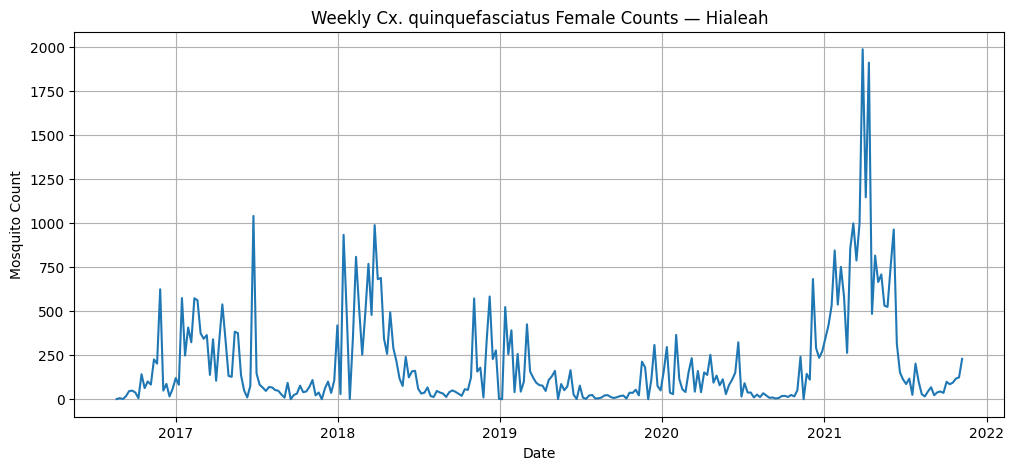

In [6]:
# ============================================================
# 4. Exploratory Visualization
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(ts_hialeah.index, ts_hialeah["mosquito_count"])
plt.title("Weekly Cx. quinquefasciatus Female Counts — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.show()

In [7]:
# ============================================================
# 5. Evaluation Framework
# ============================================================

ts_series = ts_hialeah["mosquito_count"]

train_size = int(len(ts_series) * 0.8)

train_series = ts_series.iloc[:train_size]
test_series = ts_series.iloc[train_size:]

print("Train size:", len(train_series))
print("Test size:", len(test_series))
print("Train period:", train_series.index.min(), "to", train_series.index.max())
print("Test period:", test_series.index.min(), "to", test_series.index.max())


def compute_metrics(y_true, y_pred):
    """
    Computes forecast evaluation metrics.

    MAPE is calculated safely by ignoring points where y_true = 0.
    SMAPE is added because mosquito counts may contain zeros.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0
    if np.sum(smape_mask) > 0:
        smape = np.mean(
            np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denominator[smape_mask]
        ) * 100
    else:
        smape = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": nrmse,
        "MAPE": mape,
        "SMAPE": smape
    }


model_results = []

def add_result(model_name, y_true, y_pred):
    metrics = compute_metrics(y_true, y_pred)
    model_results.append({
        "City": "Hialeah",
        "Model": model_name,
        **metrics
    })
    return metrics

Train size: 218
Test size: 55
Train period: 2016-08-21 00:00:00 to 2020-10-18 00:00:00
Test period: 2020-10-25 00:00:00 to 2021-11-07 00:00:00


In [8]:
# ============================================================
# 6. Baseline Models
# Research Question:
# How much forecasting skill can be achieved using only simple
# temporal persistence and smoothing rules?
# ============================================================

def naive_forecast(train):
    return train.iloc[-1]

def seasonal_naive_forecast(train, season_length=52):
    if len(train) < season_length:
        return train.iloc[-1]
    return train.iloc[-season_length]

def rolling_mean_forecast(train, window=4):
    return train.iloc[-window:].mean()


def evaluate_expanding_baseline(ts, model_fn, initial_train_size, **kwargs):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        pred = model_fn(train, **kwargs)

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


INITIAL_TRAIN_SIZE = 52

baseline_specs = [
    ("Naive", naive_forecast, {}),
    ("Seasonal Naive", seasonal_naive_forecast, {"season_length": 52}),
    ("Rolling Mean", rolling_mean_forecast, {"window": 4})
]

for name, fn, kwargs in baseline_specs:
    y_true, y_pred = evaluate_expanding_baseline(
        ts_series,
        fn,
        initial_train_size=INITIAL_TRAIN_SIZE,
        **kwargs
    )
    
    metrics = add_result(name, y_true, y_pred)
    print(name, metrics)

baseline_df = pd.DataFrame(model_results)
baseline_df

Naive {'RMSE': 231.17546371235946, 'MAE': 133.66968325791856, 'R2': 0.38963799850061087, 'nRMSE': 1.1218167291825445, 'MAPE': 490.2417675188666, 'SMAPE': 77.1297858796008}
Seasonal Naive {'RMSE': 332.5024614613072, 'MAE': 194.3393665158371, 'R2': -0.26268128312946426, 'nRMSE': 1.6135225502382171, 'MAPE': 610.0708834443078, 'SMAPE': 101.63394094216238}
Rolling Mean {'RMSE': 200.7222747008562, 'MAE': 114.23755656108597, 'R2': 0.5398545271010322, 'nRMSE': 0.9740376511547411, 'MAPE': 492.75439993094625, 'SMAPE': 65.81807972425763}


,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Naive,231.175464,133.669683,0.389638,1.121817,490.241768,77.129786
1,Hialeah,Seasonal Naive,332.502461,194.339367,-0.262681,1.613523,610.070883,101.633941
2,Hialeah,Rolling Mean,200.722275,114.237557,0.539855,0.974038,492.754400,65.818080


In [ ]:
# ============================================================
# 2. Data Loading
# ============================================================

univariate_city_path = r"C:\Users\ajha26\Desktop\Research\Code\Statistical Time Series\Miami_and_Hialeah_alltraps.xlsx"

df_city = pd.read_excel(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-01-05,2,E5,Miami
1,2016-01-05,3,E1,Miami
2,2016-01-12,2,KB1,Miami
3,2016-01-12,1,E2,Miami
4,2016-01-12,6,VK1,Miami


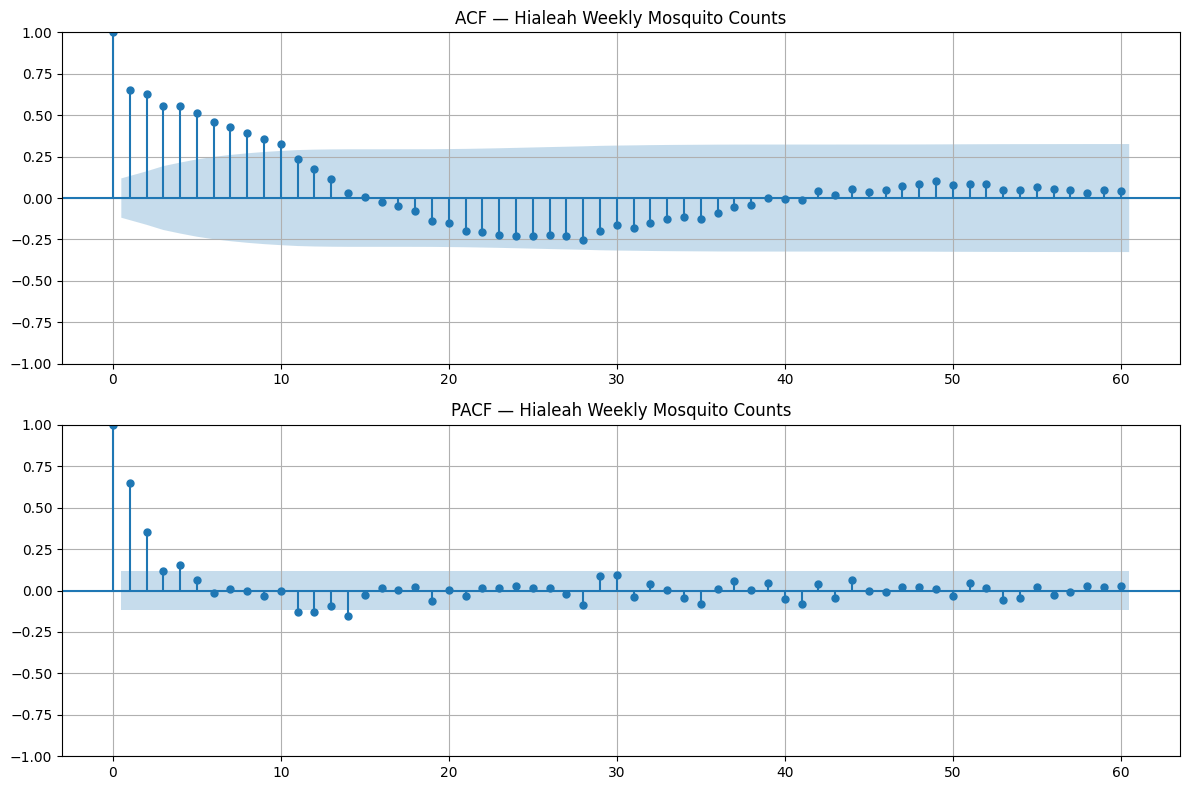

In [9]:
# ============================================================
# 7. Autocorrelation Analysis
# Research Question:
# Do mosquito counts show short-term persistence or seasonal memory?
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts_series, lags=60, ax=axes[0])
axes[0].set_title("ACF — Hialeah Weekly Mosquito Counts")

plot_pacf(ts_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Hialeah Weekly Mosquito Counts")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 8. Stationarity Tests
# ============================================================

def stationarity_tests(ts):
    """
    Runs ADF and KPSS tests.
    ADF null hypothesis: series is non-stationary.
    KPSS null hypothesis: series is stationary.
    """
    ts_clean = ts.dropna()

    adf_result = adfuller(ts_clean, autolag="AIC")
    kpss_result = kpss(ts_clean, regression="c", nlags="auto")

    return pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]]
    })

stationarity_tests(ts_series)

,Test,Statistic,p-value
0,ADF,-3.360997,0.012363
1,KPSS,0.180378,0.100000


In [11]:
# ============================================================
# 9. Residual Diagnostic Function
# ============================================================

def residual_diagnostics(residuals, fitted_values=None, title="Residual Diagnostics"):
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals Over Time")

    if fitted_values is not None:
        fitted_values = np.array(fitted_values)
        min_len = min(len(fitted_values), len(residuals))
        axes[0, 1].scatter(fitted_values[-min_len:], residuals[-min_len:])
        axes[0, 1].axhline(0, linestyle="--")
        axes[0, 1].set_title("Residuals vs Fitted")
    else:
        axes[0, 1].hist(residuals, bins=25)
        axes[0, 1].set_title("Residual Distribution")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF of Residuals")

    qqplot(residuals, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Ljung-Box Test:")
    display(acorr_ljungbox(residuals, lags=[10, 20], return_df=True))

In [12]:
# ============================================================
# 10. ARIMA Hyperparameter Tuning
# Research Question:
# Can tuned ARIMA models outperform simple temporal baselines?
# ============================================================

def tune_arima(train, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                try:
                    model = ARIMA(train, order=order)
                    fitted = model.fit()

                    results.append({
                        "order": order,
                        "AIC": fitted.aic,
                        "BIC": fitted.bic
                    })

                except Exception:
                    continue

    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


arima_tuning_results = tune_arima(
    train_series,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

arima_tuning_results.head(10)

,order,AIC,BIC
0,"(4, 0, 3)",18.000000,48.460456
1,"(2, 1, 3)",2827.852863,2848.132247
2,"(4, 1, 3)",2829.540015,2856.579193
3,"(3, 1, 3)",2830.002111,2853.661393
4,"(2, 1, 4)",2830.058141,2853.717422
5,"(3, 1, 4)",2830.345769,2857.384948
6,"(4, 0, 4)",2830.837454,2864.682405
7,"(0, 1, 1)",2831.095773,2837.855568
8,"(4, 1, 0)",2831.732455,2848.631942
9,"(0, 1, 4)",2831.998051,2848.897538


Best ARIMA order: (4, 0, 3)
{'RMSE': 509.745823012604, 'MAE': 328.96801046056095, 'R2': -0.3598982670786093, 'nRMSE': 1.2409711519871292, 'MAPE': 130.84019505612028, 'SMAPE': 97.24366061136269}


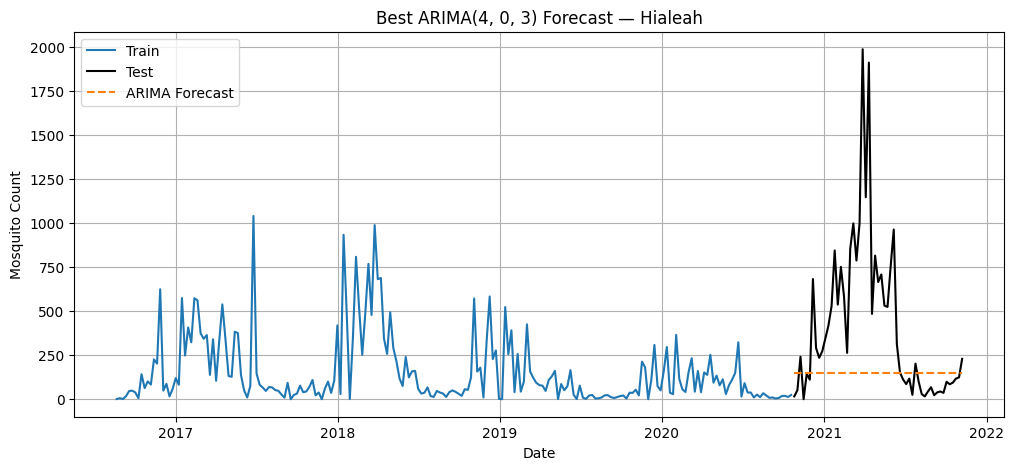

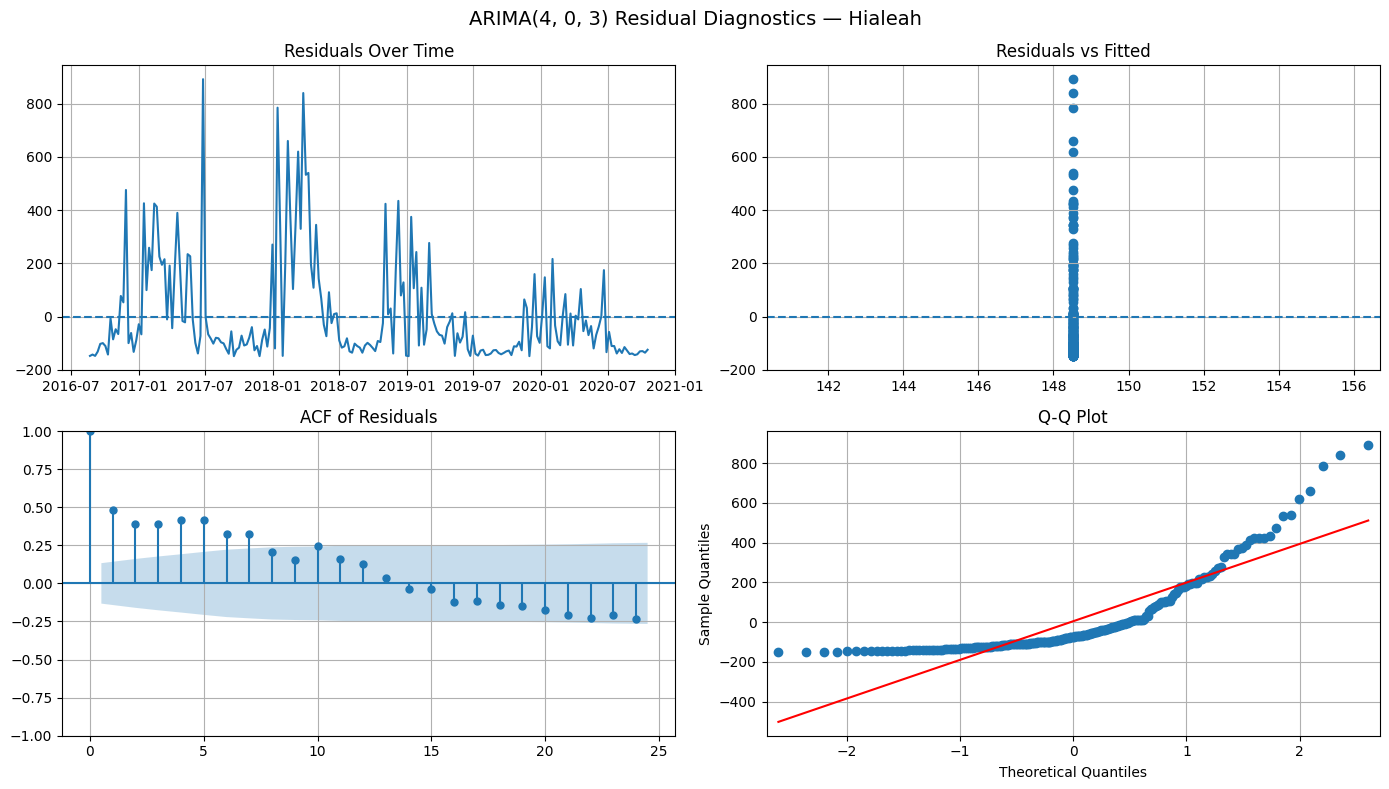

Ljung-Box Test:


,lb_stat,lb_pvalue
10,274.632166,3.530204e-53
20,309.929748,7.546592e-54


In [13]:
# ============================================================
# 11. Best One-Shot ARIMA Evaluation
# ============================================================

best_arima_order = arima_tuning_results.iloc[0]["order"]
print("Best ARIMA order:", best_arima_order)

best_arima = ARIMA(train_series, order=best_arima_order).fit()

arima_forecast = best_arima.forecast(steps=len(test_series))
arima_forecast.index = test_series.index
arima_forecast = np.maximum(arima_forecast, 0)

metrics = add_result(f"ARIMA{best_arima_order}", test_series, arima_forecast)
print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.title(f"Best ARIMA{best_arima_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_arima.resid,
    fitted_values=best_arima.fittedvalues,
    title=f"ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

In [14]:
# ============================================================
# 12. Log-Transformed ARIMA
# Research Question:
# Does stabilizing variance improve ARIMA performance?
# ============================================================

log_train = np.log1p(train_series)
log_test = np.log1p(test_series)

log_arima_tuning_results = tune_arima(
    log_train,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

log_arima_tuning_results.head(10)

,order,AIC,BIC
0,"(2, 0, 3)",716.890344,740.581809
1,"(2, 0, 4)",717.363593,744.439554
2,"(3, 0, 2)",717.392634,741.084099
3,"(3, 0, 3)",717.985281,745.061242
4,"(3, 0, 4)",720.318447,750.778902
5,"(4, 0, 4)",720.654425,754.499376
6,"(4, 0, 3)",720.948014,751.408470
7,"(1, 1, 3)",723.942593,740.842080
8,"(2, 1, 2)",724.414719,741.314206
9,"(0, 1, 3)",724.651907,738.171496


Best log-ARIMA order: (2, 0, 3)
{'RMSE': 511.5621765253076, 'MAE': 330.95866546749625, 'R2': -0.3696068575182716, 'nRMSE': 1.2453930466046352, 'MAPE': 70.27499967921504, 'SMAPE': 107.90422118951524}


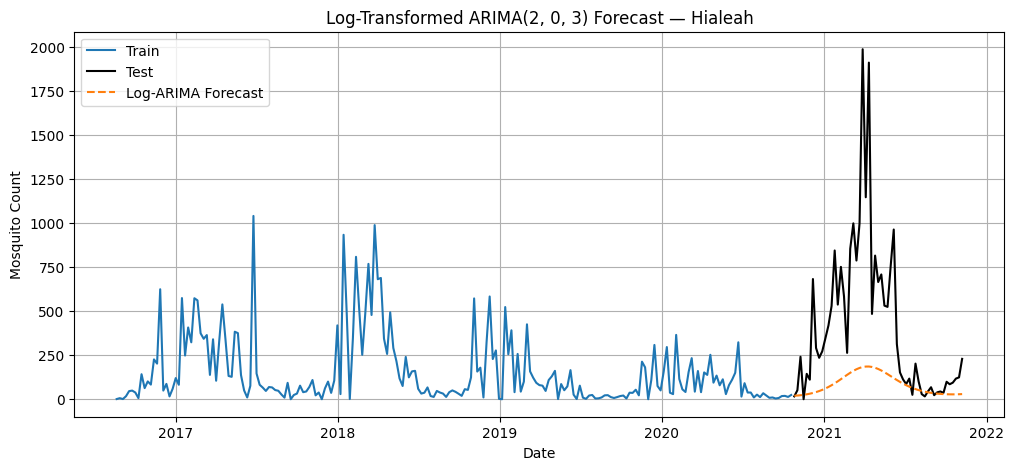

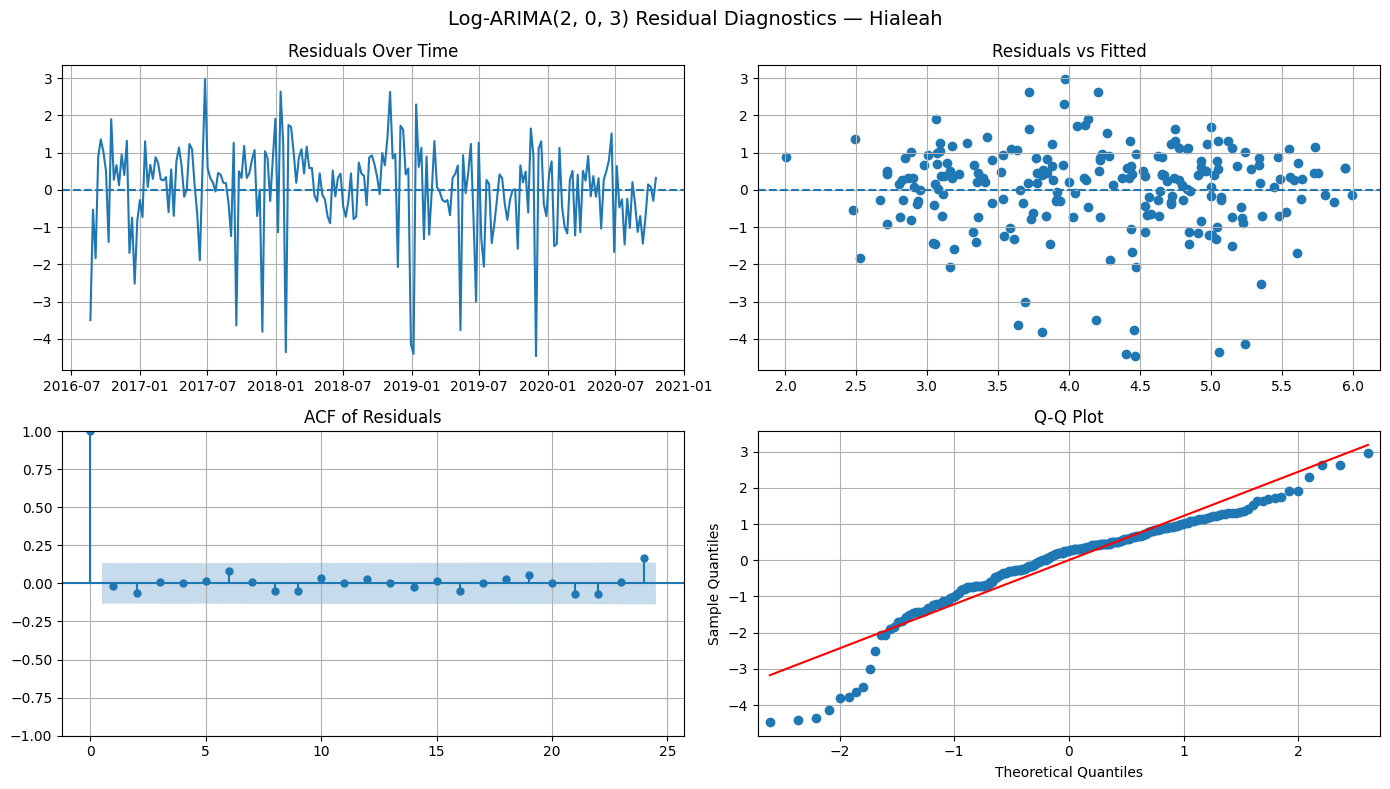

Ljung-Box Test:


,lb_stat,lb_pvalue
10,4.020799,0.946404
20,5.905596,0.999019


In [15]:
best_log_arima_order = log_arima_tuning_results.iloc[0]["order"]
print("Best log-ARIMA order:", best_log_arima_order)

best_log_arima = ARIMA(log_train, order=best_log_arima_order).fit()

log_forecast = best_log_arima.forecast(steps=len(test_series))
log_forecast.index = test_series.index

log_arima_forecast_original_scale = np.expm1(log_forecast)
log_arima_forecast_original_scale = np.maximum(log_arima_forecast_original_scale, 0)

metrics = add_result(
    f"Log-ARIMA{best_log_arima_order}",
    test_series,
    log_arima_forecast_original_scale
)

print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_arima_forecast_original_scale.index,
    log_arima_forecast_original_scale,
    label="Log-ARIMA Forecast",
    linestyle="--"
)
plt.title(f"Log-Transformed ARIMA{best_log_arima_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_log_arima.resid,
    fitted_values=best_log_arima.fittedvalues,
    title=f"Log-ARIMA{best_log_arima_order} Residual Diagnostics — Hialeah"
)

In [16]:
# ============================================================
# 13. Rolling ARIMA
# ============================================================

def rolling_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1).iloc[0]
            pred = max(pred, 0)
        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_arima, y_pred_roll_arima = rolling_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_arima = compute_metrics(y_true_roll_arima, y_pred_roll_arima)
print(metrics_roll_arima)

add_result(
    f"Rolling ARIMA{best_arima_order}",
    y_true_roll_arima,
    y_pred_roll_arima
)

{'RMSE': 208.013287826578, 'MAE': 130.7687059111317, 'R2': 0.50581885591537, 'nRMSE': 1.009418484249127, 'MAPE': 573.6101608364584, 'SMAPE': 79.45763713714473}


{'RMSE': 208.013287826578,
 'MAE': 130.7687059111317,
 'R2': 0.50581885591537,
 'nRMSE': 1.009418484249127,
 'MAPE': 573.6101608364584,
 'SMAPE': 79.45763713714473}

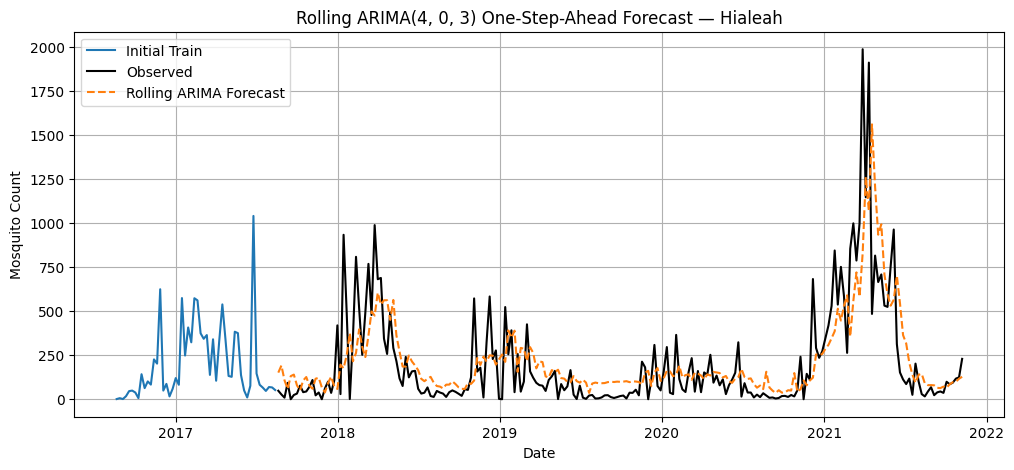

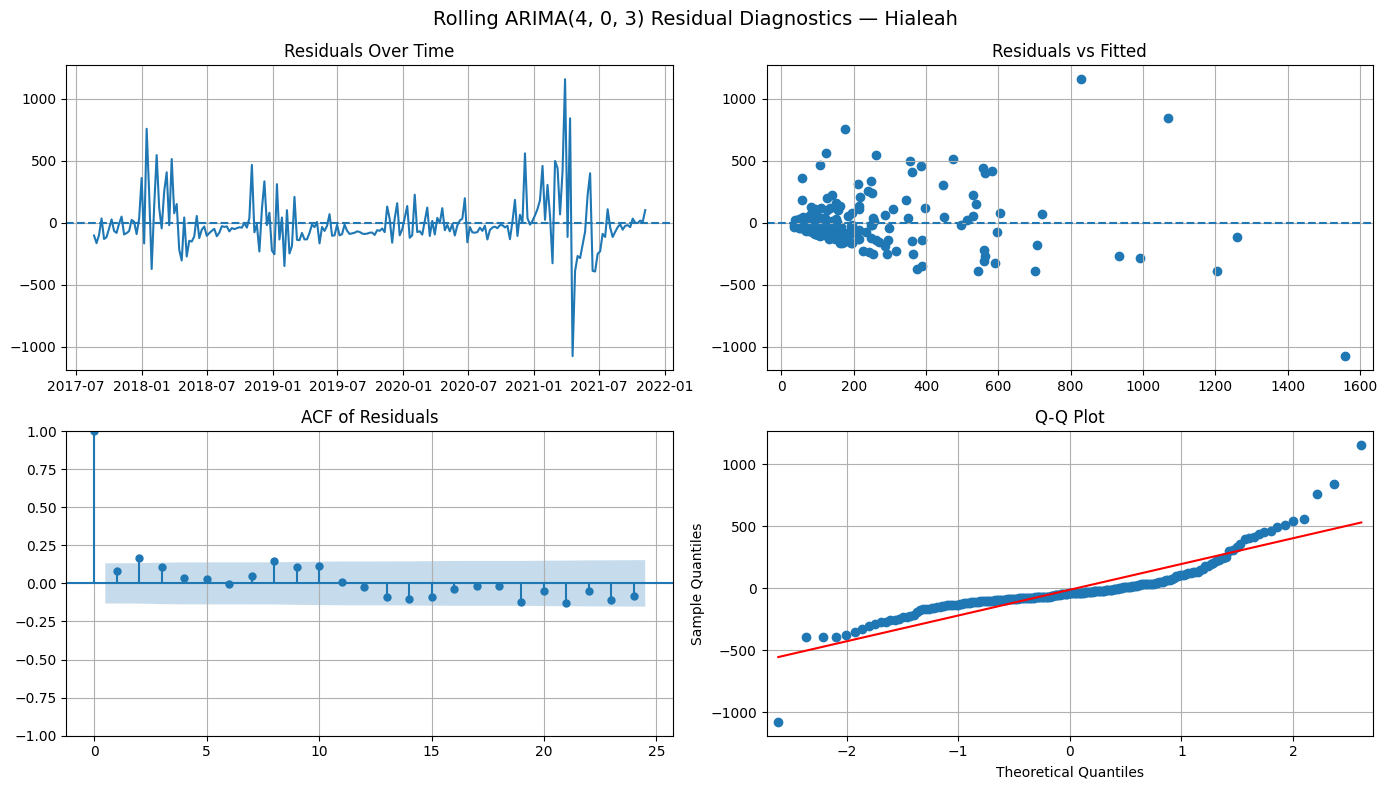

Ljung-Box Test:


,lb_stat,lb_pvalue
10,21.798352,0.016165
20,32.997034,0.033766


,lb_stat,lb_pvalue
10,21.798352,0.016165
20,32.997034,0.033766
30,46.185572,0.029831


In [17]:
# ============================================================
# 14. Rolling ARIMA Forecast Plot and Diagnostics
# ============================================================

rolling_start_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_arima_true = pd.Series(
    y_true_roll_arima,
    index=rolling_start_index,
    name="True"
)

rolling_arima_pred = pd.Series(
    y_pred_roll_arima,
    index=rolling_start_index,
    name="Rolling ARIMA Forecast"
)

rolling_arima_residuals = rolling_arima_true - rolling_arima_pred

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_arima_true.index,
    rolling_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_arima_pred.index,
    rolling_arima_pred,
    label="Rolling ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling ARIMA{best_arima_order} One-Step-Ahead Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    rolling_arima_residuals,
    fitted_values=rolling_arima_pred,
    title=f"Rolling ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        rolling_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [18]:
# ============================================================
# 15. Rolling Log-ARIMA
# ============================================================

def rolling_log_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        log_train = np.log1p(train)

        try:
            model = ARIMA(log_train, order=order)
            fitted = model.fit()

            log_pred = fitted.forecast(steps=1).iloc[0]
            pred = np.expm1(log_pred)
            pred = max(pred, 0)

        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_log_arima, y_pred_roll_log_arima = rolling_log_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_log_arima = compute_metrics(
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

print(metrics_roll_log_arima)

add_result(
    f"Rolling Log-ARIMA{best_arima_order}",
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

{'RMSE': 241.28467228831062, 'MAE': 133.64381185870624, 'R2': 0.3350890552864122, 'nRMSE': 1.170873316405003, 'MAPE': 321.3774920518965, 'SMAPE': 80.20597241032064}


{'RMSE': 241.28467228831062,
 'MAE': 133.64381185870624,
 'R2': 0.3350890552864122,
 'nRMSE': 1.170873316405003,
 'MAPE': 321.3774920518965,
 'SMAPE': 80.20597241032064}

In [41]:
# ============================================================
# Rolling Log-ARIMA Forecast Plot and Diagnostics
# ============================================================

rolling_log_arima_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_log_arima_true = pd.Series(
    y_true_roll_log_arima,
    index=rolling_log_arima_index,
    name="Observed"
)

rolling_log_arima_pred = pd.Series(
    y_pred_roll_log_arima,
    index=rolling_log_arima_index,
    name="Rolling Log-ARIMA Forecast"
)

rolling_log_arima_residuals = rolling_log_arima_true - rolling_log_arima_pred

In [19]:
# ============================================================
# 16. ARIMA Summary Table
# ============================================================

arima_results = []

def add_arima_result(model_name, order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)

    if fitted_model is not None:
        aic = fitted_model.aic
        bic = fitted_model.bic
    else:
        aic = np.nan
        bic = np.nan

    arima_results.append({
        "Model": model_name,
        "Order": str(order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": aic,
        "BIC": bic
    })


add_arima_result(
    model_name="ARIMA One-Shot",
    order=best_arima_order,
    y_true=test_series,
    y_pred=arima_forecast,
    fitted_model=best_arima
)

add_arima_result(
    model_name="Log-ARIMA One-Shot",
    order=best_log_arima_order,
    y_true=test_series,
    y_pred=log_arima_forecast_original_scale,
    fitted_model=best_log_arima
)

add_arima_result(
    model_name="Rolling ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None
)

add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("RMSE").reset_index(drop=True)

arima_results_df

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 0, 3)",208.013288,130.768706,0.505819,1.009418,573.610161,79.457637,NaN,NaN
1,Rolling Log-ARIMA,"(4, 0, 3)",241.284672,133.643812,0.335089,1.170873,321.377492,80.205972,NaN,NaN
2,ARIMA One-Shot,"(4, 0, 3)",509.745823,328.968010,-0.359898,1.240971,130.840195,97.243661,18.000000,48.460456
3,Log-ARIMA One-Shot,"(2, 0, 3)",511.562177,330.958665,-0.369607,1.245393,70.275000,107.904221,716.890344,740.581809


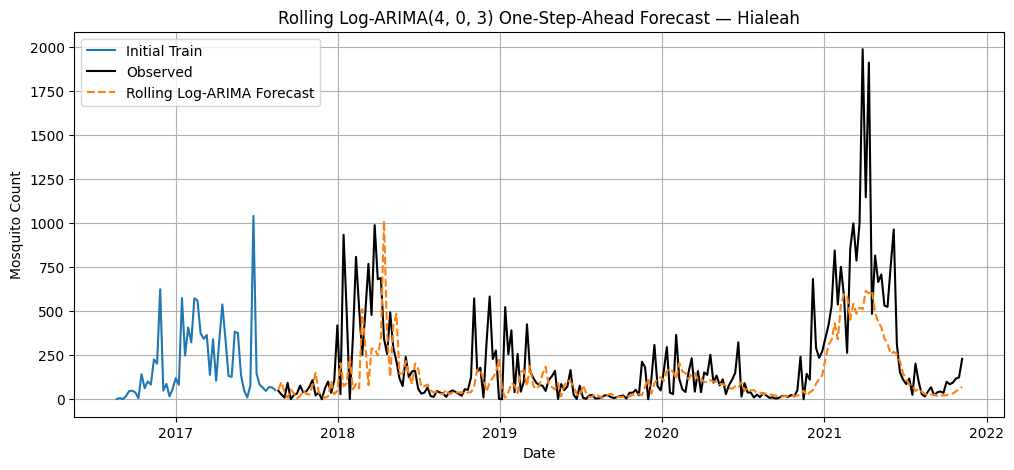

In [42]:
# ============================================================
# Forecast Plot: Rolling Log-ARIMA
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-ARIMA{best_arima_order} One-Step-Ahead Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

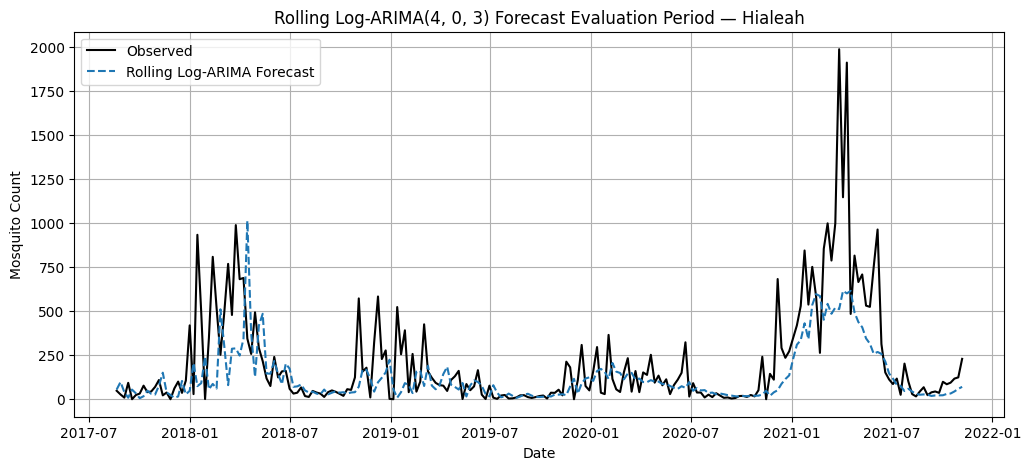

In [43]:
# ============================================================
# Zoomed Forecast Plot: Rolling Log-ARIMA Evaluation Period Only
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-ARIMA{best_arima_order} Forecast Evaluation Period — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

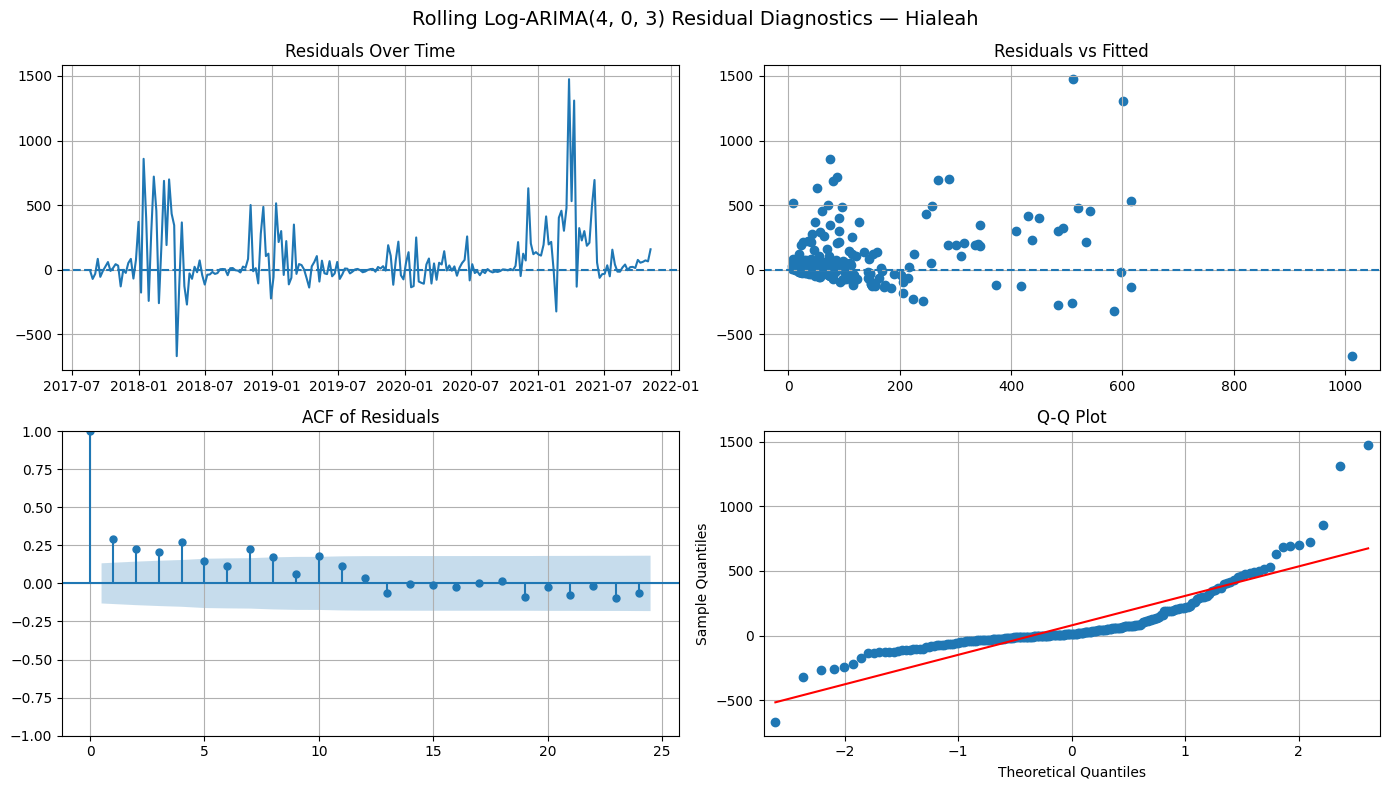

Ljung-Box Test:


,lb_stat,lb_pvalue
10,92.681802,1.571563e-15
20,99.407854,1.607467e-12


In [44]:
# ============================================================
# Residual Diagnostics: Rolling Log-ARIMA
# ============================================================

residual_diagnostics(
    rolling_log_arima_residuals,
    fitted_values=rolling_log_arima_pred,
    title=f"Rolling Log-ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

In [45]:
# ============================================================
# Ljung-Box Test: Rolling Log-ARIMA Residuals
# ============================================================

display(
    acorr_ljungbox(
        rolling_log_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

,lb_stat,lb_pvalue
10,92.681802,1.571563e-15
20,99.407854,1.607467e-12
30,111.391025,2.724389e-11


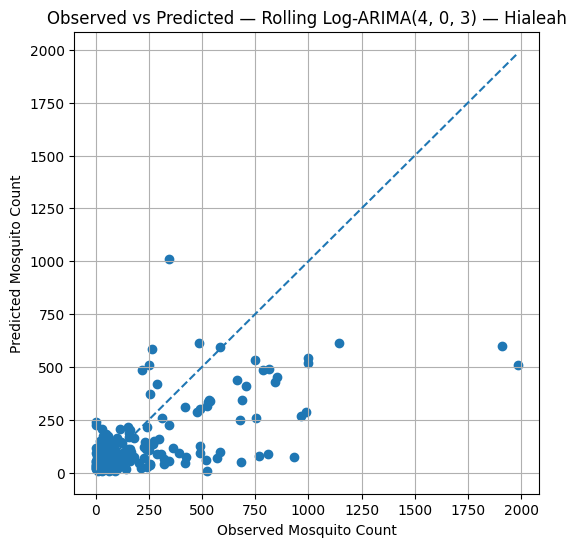

In [46]:
# ============================================================
# Actual vs Predicted Scatter Plot: Rolling Log-ARIMA
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(rolling_log_arima_true, rolling_log_arima_pred)

min_val = min(rolling_log_arima_true.min(), rolling_log_arima_pred.min())
max_val = max(rolling_log_arima_true.max(), rolling_log_arima_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Observed vs Predicted — Rolling Log-ARIMA{best_arima_order} — Hialeah")
plt.xlabel("Observed Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.show()

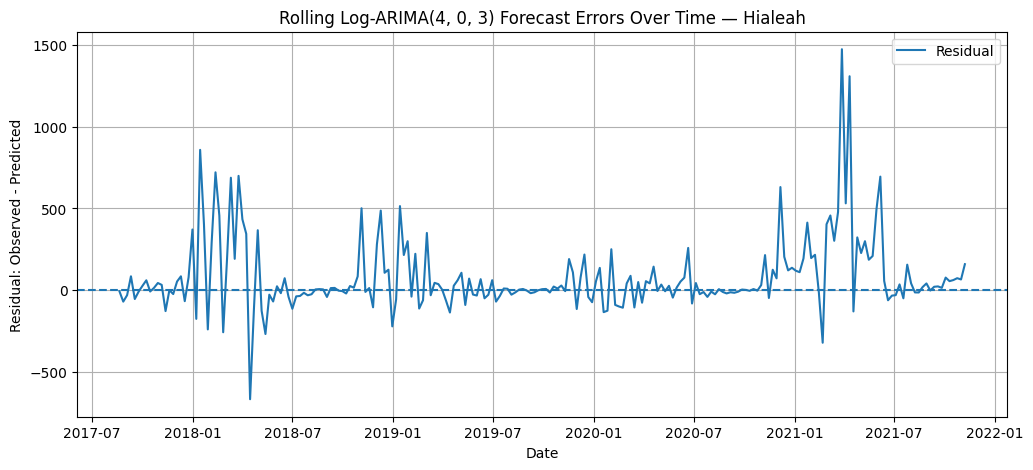

In [47]:
# ============================================================
# Rolling Log-ARIMA Error Over Time
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_arima_residuals.index,
    rolling_log_arima_residuals,
    label="Residual"
)

plt.axhline(0, linestyle="--")

plt.title(f"Rolling Log-ARIMA{best_arima_order} Forecast Errors Over Time — Hialeah")
plt.xlabel("Date")
plt.ylabel("Residual: Observed - Predicted")
plt.legend()
plt.show()

In [20]:
arima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 0, 3)",208.01,130.77,0.506,1.009,573.61,79.46,nan,nan
1,Rolling Log-ARIMA,"(4, 0, 3)",241.28,133.64,0.335,1.171,321.38,80.21,nan,nan
2,ARIMA One-Shot,"(4, 0, 3)",509.75,328.97,-0.360,1.241,130.84,97.24,18.00,48.46
3,Log-ARIMA One-Shot,"(2, 0, 3)",511.56,330.96,-0.370,1.245,70.27,107.90,716.89,740.58


In [48]:
add_arima_result(
    model_name="Rolling ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None
)

add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

In [21]:
# ============================================================
# 17. SARIMA Modeling
# Research Question:
# Does explicitly modeling annual seasonality improve mosquito
# count forecasting compared with non-seasonal ARIMA?
# ============================================================

import itertools
import time

In [22]:
# ============================================================
# 18. Small SARIMA Hyperparameter Tuning
# ============================================================

def tune_sarima_small(train, seasonal_period=52):
    """
    Small SARIMA tuning grid designed to run in reasonable time.
    """
    
    candidate_orders = [
        (1, 0, 0),
        (1, 0, 1),
        (2, 0, 1),
        (3, 0, 1),
        (3, 0, 2),
        (3, 0, 4),
    ]
    
    candidate_seasonal_orders = [
        (0, 0, 0, seasonal_period),
        (1, 0, 0, seasonal_period),
        (0, 0, 1, seasonal_period),
        (1, 0, 1, seasonal_period),
        (1, 1, 0, seasonal_period),
        (0, 1, 1, seasonal_period),
    ]
    
    results = []
    
    start_time = time.time()
    
    for order in candidate_orders:
        for seasonal_order in candidate_seasonal_orders:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                fitted = model.fit(disp=False, maxiter=75)
                
                results.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
                
                print(f"Finished SARIMA{order}{seasonal_order} | AIC: {fitted.aic:.2f}")
            
            except Exception as e:
                print(f"Failed SARIMA{order}{seasonal_order}: {e}")
                continue
    
    elapsed = time.time() - start_time
    print(f"\nTuning completed in {elapsed/60:.2f} minutes")
    
    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


sarima_tuning_results = tune_sarima_small(
    train_series,
    seasonal_period=52
)

sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 2877.45
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 2144.60
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 2155.38
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 2127.03
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 1495.57
Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 2968.92
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 2817.98
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 2116.74
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 2108.32
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 2103.23
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 1484.72
Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 3020.03
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 2819.92
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 2106.93
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 2110.30
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 2104.15
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 1474.31
Finished SARIMA(2, 0, 1)(0, 1, 1, 52) | AIC: 2896.32
Finished SARIMA(3, 0, 1)(0, 0, 0, 52) | AIC: 2

,order,seasonal_order,AIC,BIC
0,"(3, 0, 2)","(0, 1, 1, 52)",14.000000,32.966711
1,"(3, 0, 4)","(1, 1, 0, 52)",1450.802815,1475.188587
2,"(3, 0, 2)","(1, 1, 0, 52)",1456.482148,1475.448859
3,"(3, 0, 1)","(1, 1, 0, 52)",1462.954257,1479.211439
4,"(2, 0, 1)","(1, 1, 0, 52)",1474.311302,1487.903796
5,"(1, 0, 1)","(1, 1, 0, 52)",1484.724608,1495.634159
6,"(1, 0, 0)","(1, 1, 0, 52)",1495.571323,1503.753486
7,"(3, 0, 4)","(1, 0, 1, 52)",2064.034684,2094.848728
8,"(3, 0, 4)","(0, 0, 1, 52)",2073.571861,2101.304500
9,"(3, 0, 2)","(1, 0, 1, 52)",2087.372849,2112.122851


In [23]:
# ============================================================
# 19. Best One-Shot SARIMA Forecast
# ============================================================

best_sarima_order = sarima_tuning_results.iloc[0]["order"]
best_sarima_seasonal_order = sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best SARIMA order:", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

best_sarima = SARIMAX(
    train_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

sarima_forecast = best_sarima.forecast(steps=len(test_series))
sarima_forecast.index = test_series.index
sarima_forecast = np.maximum(sarima_forecast, 0)

sarima_metrics = compute_metrics(test_series, sarima_forecast)
print(sarima_metrics)

add_result(
    f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    test_series,
    sarima_forecast
)

Best SARIMA order: (3, 0, 2)
Best SARIMA seasonal order: (0, 1, 1, 52)
{'RMSE': 1.656755915465031e+33, 'MAE': 5.522422586975672e+32, 'R2': -1.436534725516807e+61, 'nRMSE': 4.033355849441249e+30, 'MAPE': 5.848318299299396e+32, 'SMAPE': 200.0}


{'RMSE': 1.656755915465031e+33,
 'MAE': 5.522422586975672e+32,
 'R2': -1.436534725516807e+61,
 'nRMSE': 4.033355849441249e+30,
 'MAPE': 5.848318299299396e+32,
 'SMAPE': 200.0}

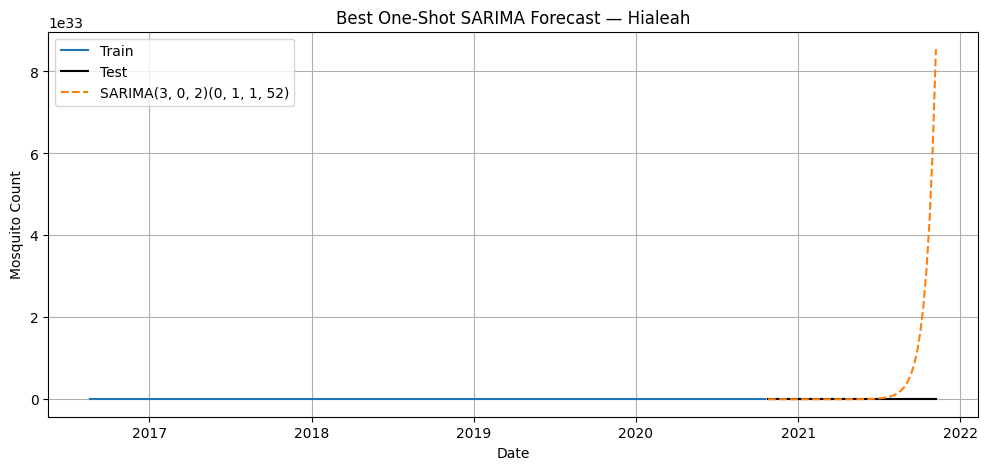

In [24]:
# ============================================================
# 20. One-Shot SARIMA Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot SARIMA Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

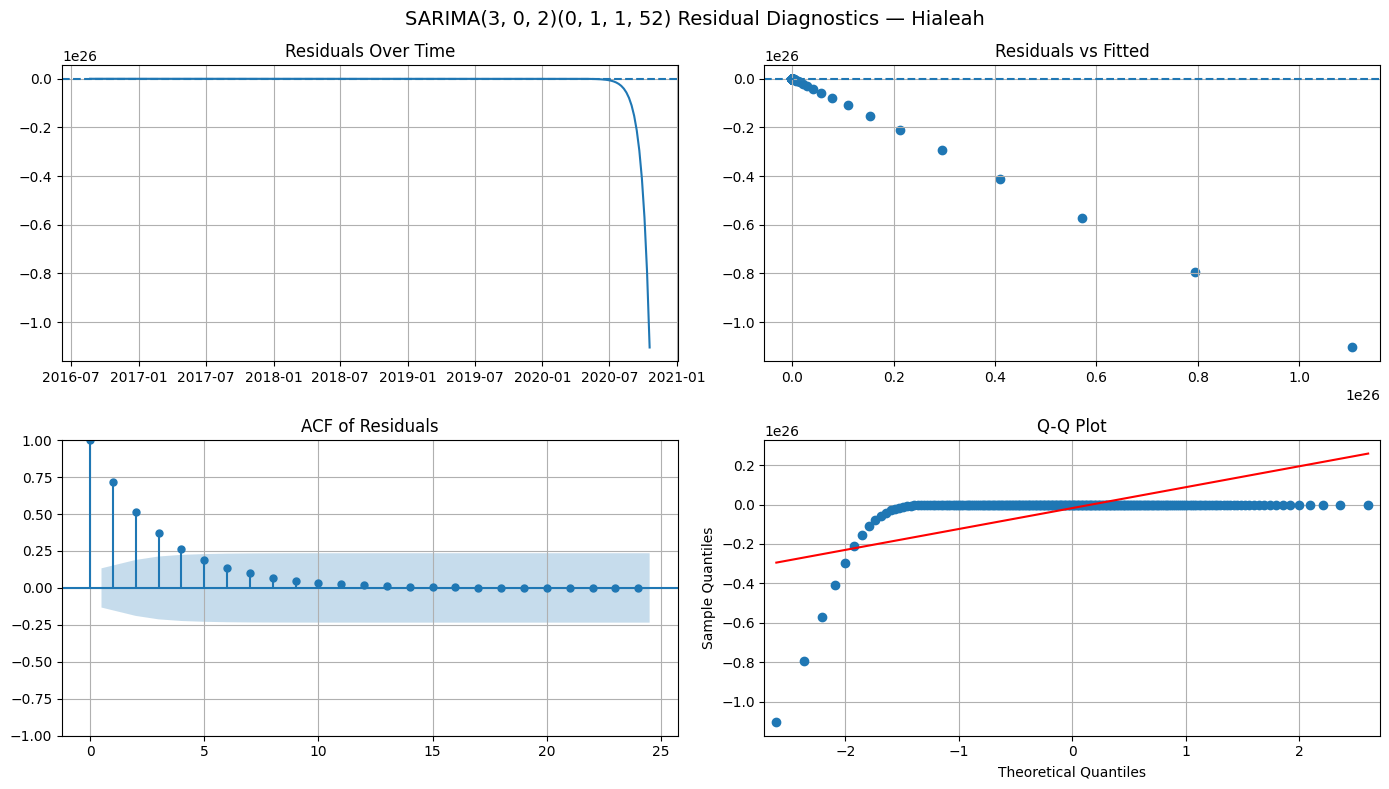

Ljung-Box Test:


,lb_stat,lb_pvalue
10,236.563000,3.607975e-45
20,236.835689,5.090773e-39


,lb_stat,lb_pvalue
10,236.563000,3.607975e-45
20,236.835689,5.090773e-39
30,236.859948,5.112829e-34


In [25]:
# ============================================================
# 21. One-Shot SARIMA Residual Diagnostics
# ============================================================

residual_diagnostics(
    best_sarima.resid,
    fitted_values=best_sarima.fittedvalues,
    title=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [26]:
# ============================================================
# 22. Faster Rolling SARIMA Forecast
# ============================================================

def fast_rolling_sarima_forecast(
    ts,
    order,
    seasonal_order,
    initial_train_size,
    refit_every=8,
    maxiter=25
):
    """
    Faster rolling one-step-ahead SARIMA forecast.
    """
    
    y_true, y_pred = [], []
    pred_index = []
    
    start_time = time.time()
    
    i = initial_train_size
    
    while i < len(ts):
        train = ts.iloc[:i]
        
        steps = min(refit_every, len(ts) - i)
        test_block = ts.iloc[i:i + steps]
        
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                simple_differencing=True
            )
            
            fitted = model.fit(
                disp=False,
                maxiter=maxiter,
                method="powell"
            )
            
            forecast = fitted.forecast(steps=steps)
            forecast = np.maximum(forecast.values, 0)
        
        except Exception:
            forecast = np.repeat(train.iloc[-1], steps)
        
        y_true.extend(test_block.values)
        y_pred.extend(forecast)
        pred_index.extend(test_block.index)
        
        print(f"Completed forecasts through index {i + steps} / {len(ts)}")
        
        i += steps
    
    elapsed = time.time() - start_time
    print(f"\nFast rolling SARIMA completed in {elapsed/60:.2f} minutes")
    
    return (
        np.array(y_true),
        np.array(y_pred),
        pd.Index(pred_index)
    )

In [27]:
fast_sarima_order = best_sarima_order
fast_sarima_seasonal_order = best_sarima_seasonal_order

y_true_roll_sarima, y_pred_roll_sarima, roll_sarima_index = fast_rolling_sarima_forecast(
    ts_series,
    order=fast_sarima_order,
    seasonal_order=fast_sarima_seasonal_order,
    initial_train_size=INITIAL_TRAIN_SIZE,
    refit_every=8,
    maxiter=25
)

rolling_sarima_metrics = compute_metrics(
    y_true_roll_sarima,
    y_pred_roll_sarima
)

print(rolling_sarima_metrics)

add_result(
    f"Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order}",
    y_true_roll_sarima,
    y_pred_roll_sarima
)

Completed forecasts through index 60 / 273
Completed forecasts through index 68 / 273
Completed forecasts through index 76 / 273
Completed forecasts through index 84 / 273
Completed forecasts through index 92 / 273
Completed forecasts through index 100 / 273
Completed forecasts through index 108 / 273
Completed forecasts through index 116 / 273
Completed forecasts through index 124 / 273
Completed forecasts through index 132 / 273
Completed forecasts through index 140 / 273
Completed forecasts through index 148 / 273
Completed forecasts through index 156 / 273
Completed forecasts through index 164 / 273
Completed forecasts through index 172 / 273
Completed forecasts through index 180 / 273
Completed forecasts through index 188 / 273
Completed forecasts through index 196 / 273
Completed forecasts through index 204 / 273
Completed forecasts through index 212 / 273
Completed forecasts through index 220 / 273
Completed forecasts through index 228 / 273
Completed forecasts through index 236

{'RMSE': 1.606492263058316e+99,
 'MAE': 1.1397667950053684e+98,
 'R2': -2.9475507421084847e+193,
 'nRMSE': 7.795766328573357e+96,
 'MAPE': 6.1181696429110665e+96,
 'SMAPE': 163.2721968025956}

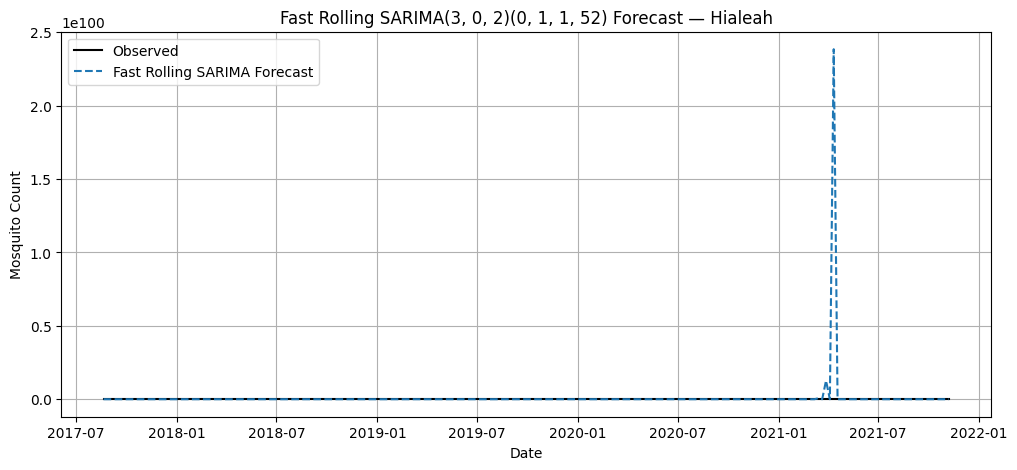

In [28]:
# ============================================================
# 23. Rolling SARIMA Forecast Plot
# ============================================================

rolling_sarima_true = pd.Series(
    y_true_roll_sarima,
    index=roll_sarima_index,
    name="Observed"
)

rolling_sarima_pred = pd.Series(
    y_pred_roll_sarima,
    index=roll_sarima_index,
    name="Fast Rolling SARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_sarima_true.index,
    rolling_sarima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_sarima_pred.index,
    rolling_sarima_pred,
    label="Fast Rolling SARIMA Forecast",
    linestyle="--"
)

plt.title(f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

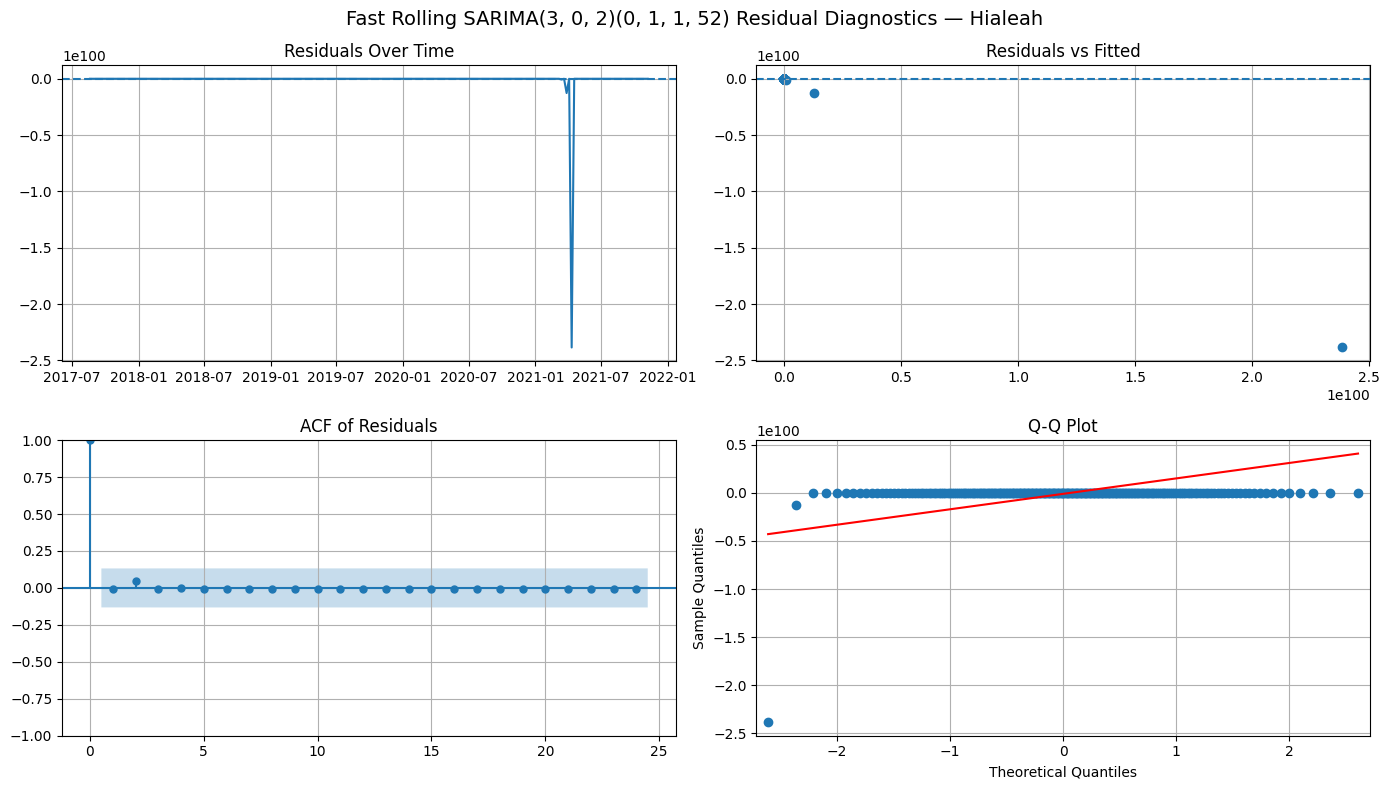

Ljung-Box Test:


,lb_stat,lb_pvalue
10,0.577405,0.999987
20,0.647743,1.000000


,lb_stat,lb_pvalue
10,0.577405,0.999987
20,0.647743,1.000000
30,0.728065,1.000000


In [29]:
# ============================================================
# 24. Rolling SARIMA Residual Diagnostics
# ============================================================

rolling_sarima_residuals = rolling_sarima_true - rolling_sarima_pred

residual_diagnostics(
    rolling_sarima_residuals,
    fitted_values=rolling_sarima_pred,
    title=f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        rolling_sarima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [30]:
# ============================================================
# 25. ETS Models
# Research Question:
# Can smoothing-based models capture mosquito count dynamics
# better than ARIMA-family models?
# ============================================================

ets_results = []
ets_fits = {}
ets_forecasts = {}

ets_configs = [
    {"trend": None, "seasonal": None, "damped_trend": False, "name": "ETS Simple"},
    {"trend": "add", "seasonal": None, "damped_trend": False, "name": "ETS Additive Trend"},
    {"trend": "add", "seasonal": None, "damped_trend": True, "name": "ETS Damped Trend"},
    {"trend": None, "seasonal": "add", "damped_trend": False, "name": "ETS Additive Seasonality"},
    {"trend": "add", "seasonal": "add", "damped_trend": False, "name": "ETS Add Trend + Add Season"},
    {"trend": "add", "seasonal": "add", "damped_trend": True, "name": "ETS Damped Trend + Add Season"},
]

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        forecast = fitted.forecast(len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        ets_results.append({
            "Model": config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        ets_fits[config["name"]] = fitted
        ets_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

ets_results_df = pd.DataFrame(ets_results).sort_values("RMSE").reset_index(drop=True)
ets_results_df

ETS Simple {'RMSE': 587.8677741255635, 'MAE': 393.84880309707756, 'R2': -0.8086660058634487, 'nRMSE': 1.4311582673913772, 'MAPE': 82.7023194665366, 'SMAPE': 151.7680607289948}
ETS Additive Trend {'RMSE': 586.3683361850343, 'MAE': 391.3481307178619, 'R2': -0.7994512677631578, 'nRMSE': 1.4275079005921072, 'MAPE': 80.4010086657329, 'SMAPE': 146.3948776147374}
ETS Damped Trend {'RMSE': 587.8372558713124, 'MAE': 393.8081376556276, 'R2': -0.8084782224920537, 'nRMSE': 1.431083971003992, 'MAPE': 82.67677766967049, 'SMAPE': 151.69467706686538}
ETS Additive Seasonality {'RMSE': 471.6328279030176, 'MAE': 301.3441239024997, 'R2': -0.1641451194592738, 'nRMSE': 1.1481854432837273, 'MAPE': 74.9461440503621, 'SMAPE': 107.1387482637369}
ETS Add Trend + Add Season {'RMSE': 466.00244509234, 'MAE': 298.1466306360754, 'R2': -0.13651575283730155, 'nRMSE': 1.134478332156458, 'MAPE': 78.30692259487296, 'SMAPE': 114.87587766149765}
ETS Damped Trend + Add Season {'RMSE': 469.427291543737, 'MAE': 298.96481404640

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,466.002445,298.146631,-0.136516,1.134478,78.306923,114.875878,2234.094768,2423.626492
1,ETS Damped Trend + Add Season,add,add,True,469.427292,298.964814,-0.153283,1.142816,74.272923,104.854256,2235.787053,2428.703272
2,ETS Additive Seasonality,None,add,False,471.632828,301.344124,-0.164145,1.148185,74.946144,107.138748,2229.906827,2412.669561
3,ETS Additive Trend,add,None,False,586.368336,391.348131,-0.799451,1.427508,80.401009,146.394878,2227.872886,2241.410866
4,ETS Damped Trend,add,None,True,587.837256,393.808138,-0.808478,1.431084,82.676778,151.694677,2228.604186,2245.526661
5,ETS Simple,None,None,False,587.867774,393.848803,-0.808666,1.431158,82.702319,151.768061,2223.773302,2230.542292


In [31]:
ets_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,466.00,298.15,-0.137,1.134,78.31,114.88,2234.09,2423.63
1,ETS Damped Trend + Add Season,add,add,True,469.43,298.96,-0.153,1.143,74.27,104.85,2235.79,2428.70
2,ETS Additive Seasonality,None,add,False,471.63,301.34,-0.164,1.148,74.95,107.14,2229.91,2412.67
3,ETS Additive Trend,add,None,False,586.37,391.35,-0.799,1.428,80.40,146.39,2227.87,2241.41
4,ETS Damped Trend,add,None,True,587.84,393.81,-0.808,1.431,82.68,151.69,2228.60,2245.53
5,ETS Simple,None,None,False,587.87,393.85,-0.809,1.431,82.70,151.77,2223.77,2230.54


In [32]:
# ============================================================
# 26. Best ETS Model
# ============================================================

best_ets_name = ets_results_df.iloc[0]["Model"]
best_ets_model = ets_fits[best_ets_name]
best_ets_forecast = ets_forecasts[best_ets_name]

print("Best ETS model:", best_ets_name)
display(ets_results_df.iloc[[0]])

Best ETS model: ETS Add Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,466.002445,298.146631,-0.136516,1.134478,78.306923,114.875878,2234.094768,2423.626492


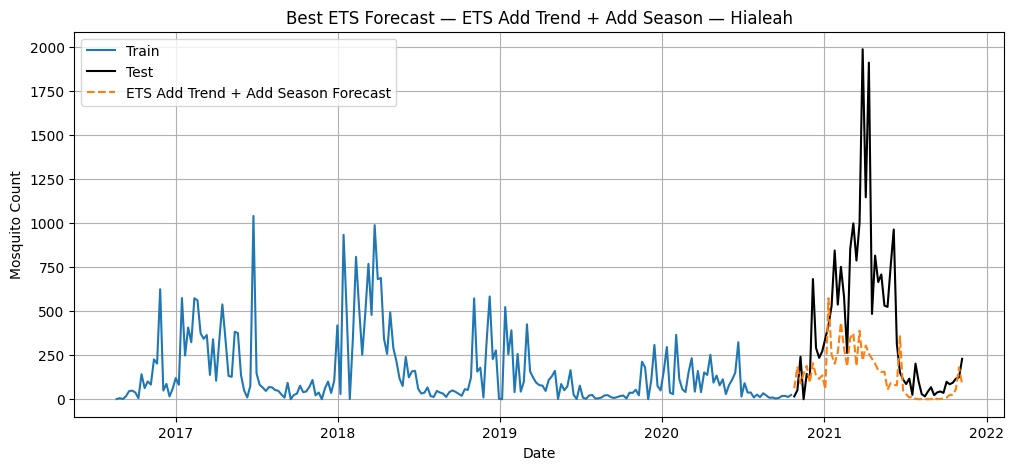

In [33]:
# ============================================================
# 27. Best ETS Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_ets_forecast.index,
    best_ets_forecast,
    label=f"{best_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best ETS Forecast — {best_ets_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

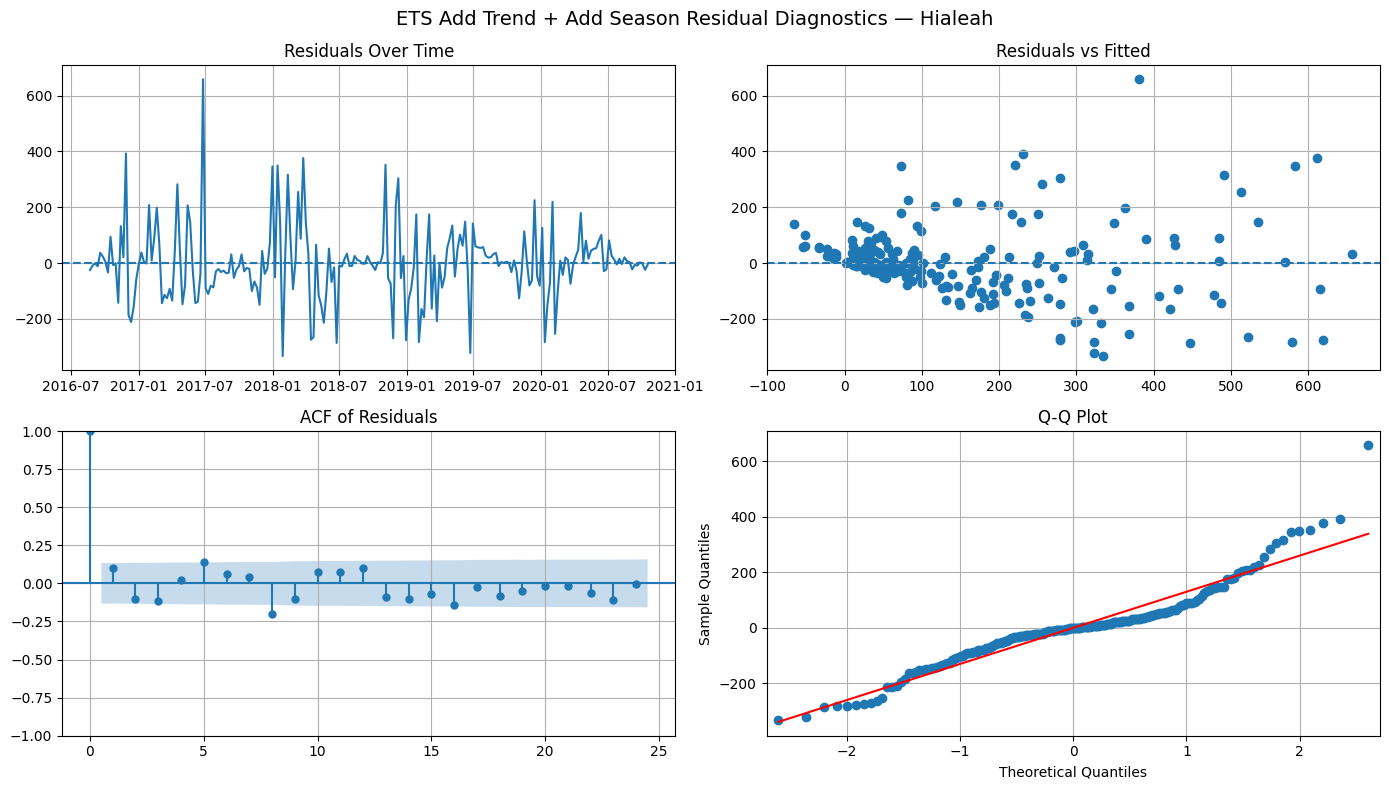

Ljung-Box Test:


,lb_stat,lb_pvalue
10,26.315681,0.003338
20,42.882880,0.002118


,lb_stat,lb_pvalue
10,26.315681,0.003338
20,42.882880,0.002118
30,62.519214,0.000451


In [34]:
# ============================================================
# 28. Best ETS Residual Diagnostics
# ============================================================

residual_diagnostics(
    best_ets_model.resid,
    fitted_values=best_ets_model.fittedvalues,
    title=f"{best_ets_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [35]:
# ============================================================
# 29. Log-ETS Models
# ============================================================

log_train_series = np.log1p(train_series)

log_ets_results = []
log_ets_fits = {}
log_ets_forecasts = {}

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            log_train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        log_forecast = fitted.forecast(len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        log_ets_results.append({
            "Model": "Log-" + config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_ets_fits["Log-" + config["name"]] = fitted
        log_ets_forecasts["Log-" + config["name"]] = forecast_original

        print("Log-" + config["name"], metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_ets_results_df = pd.DataFrame(log_ets_results).sort_values("RMSE").reset_index(drop=True)
log_ets_results_df

Log-ETS Simple {'RMSE': 589.2987728263208, 'MAE': 395.7858174409893, 'R2': -0.8174821000238404, 'nRMSE': 1.4346420195399985, 'MAPE': 84.10927921457927, 'SMAPE': 155.4835026668034}
Log-ETS Additive Trend {'RMSE': 588.2759637795203, 'MAE': 394.04064406747267, 'R2': -0.8111785949108148, 'nRMSE': 1.432152001056729, 'MAPE': 82.35545947825237, 'SMAPE': 151.36107605133168}
Log-ETS Damped Trend {'RMSE': 591.2084256171097, 'MAE': 398.5315625148137, 'R2': -0.8292804729783452, 'nRMSE': 1.4392910503249396, 'MAPE': 87.04104202822188, 'SMAPE': 161.86875937997723}
Log-ETS Additive Seasonality {'RMSE': 525.2648063412983, 'MAE': 339.7188921893717, 'R2': -0.44396170463652407, 'nRMSE': 1.2787519630298958, 'MAPE': 75.78884529385581, 'SMAPE': 121.80524013317981}
Log-ETS Add Trend + Add Season {'RMSE': 528.2202247618712, 'MAE': 342.8004681462457, 'R2': -0.46025640631516085, 'nRMSE': 1.2859468998717651, 'MAPE': 76.9241326868223, 'SMAPE': 124.63829159074169}
Log-ETS Damped Trend + Add Season {'RMSE': 531.7783

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-ETS Additive Seasonality,None,add,False,525.264806,339.718892,-0.443962,1.278752,75.788845,121.805240,129.502971,312.265704
1,Log-ETS Add Trend + Add Season,add,add,False,528.220225,342.800468,-0.460256,1.285947,76.924133,124.638292,133.461712,322.993436
2,Log-ETS Damped Trend + Add Season,add,add,True,531.778324,345.918558,-0.479995,1.294609,75.670569,124.165730,126.280198,319.196416
3,Log-ETS Additive Trend,add,None,False,588.275964,394.040644,-0.811179,1.432152,82.355459,151.361076,112.192993,125.730973
4,Log-ETS Simple,None,None,False,589.298773,395.785817,-0.817482,1.434642,84.109279,155.483503,108.213986,114.982976
5,Log-ETS Damped Trend,add,None,True,591.208426,398.531563,-0.829280,1.439291,87.041042,161.868759,104.044364,120.966839


In [36]:
# ============================================================
# 30. Combined ETS Results
# ============================================================

all_ets_results_df = pd.concat(
    [ets_results_df, log_ets_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_ets_results_df

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,466.002445,298.146631,-0.136516,1.134478,78.306923,114.875878,2234.094768,2423.626492
1,ETS Damped Trend + Add Season,add,add,True,469.427292,298.964814,-0.153283,1.142816,74.272923,104.854256,2235.787053,2428.703272
2,ETS Additive Seasonality,None,add,False,471.632828,301.344124,-0.164145,1.148185,74.946144,107.138748,2229.906827,2412.669561
3,Log-ETS Additive Seasonality,None,add,False,525.264806,339.718892,-0.443962,1.278752,75.788845,121.805240,129.502971,312.265704
4,Log-ETS Add Trend + Add Season,add,add,False,528.220225,342.800468,-0.460256,1.285947,76.924133,124.638292,133.461712,322.993436
5,Log-ETS Damped Trend + Add Season,add,add,True,531.778324,345.918558,-0.479995,1.294609,75.670569,124.165730,126.280198,319.196416
6,ETS Additive Trend,add,None,False,586.368336,391.348131,-0.799451,1.427508,80.401009,146.394878,2227.872886,2241.410866
7,ETS Damped Trend,add,None,True,587.837256,393.808138,-0.808478,1.431084,82.676778,151.694677,2228.604186,2245.526661
8,ETS Simple,None,None,False,587.867774,393.848803,-0.808666,1.431158,82.702319,151.768061,2223.773302,2230.542292
9,Log-ETS Additive Trend,add,None,False,588.275964,394.040644,-0.811179,1.432152,82.355459,151.361076,112.192993,125.730973


In [37]:
# ============================================================
# 31. Best Overall ETS or Log-ETS
# ============================================================

best_overall_ets_name = all_ets_results_df.iloc[0]["Model"]

if best_overall_ets_name.startswith("Log-"):
    best_overall_ets_model = log_ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = log_ets_forecasts[best_overall_ets_name]
else:
    best_overall_ets_model = ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = ets_forecasts[best_overall_ets_name]

print("Best overall ETS model:", best_overall_ets_name)
display(all_ets_results_df.iloc[[0]])

Best overall ETS model: ETS Add Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,466.002445,298.146631,-0.136516,1.134478,78.306923,114.875878,2234.094768,2423.626492


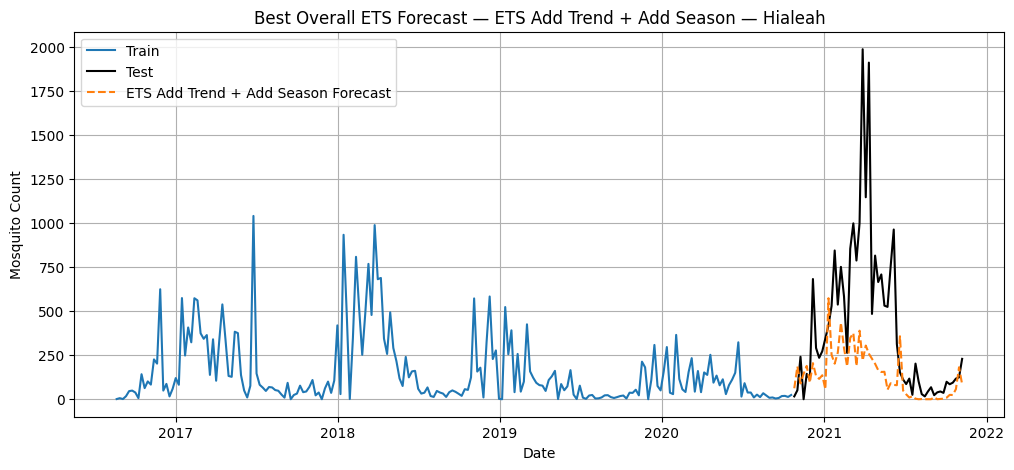

In [38]:
# ============================================================
# 32. Best Overall ETS Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_overall_ets_forecast.index,
    best_overall_ets_forecast,
    label=f"{best_overall_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall ETS Forecast — {best_overall_ets_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

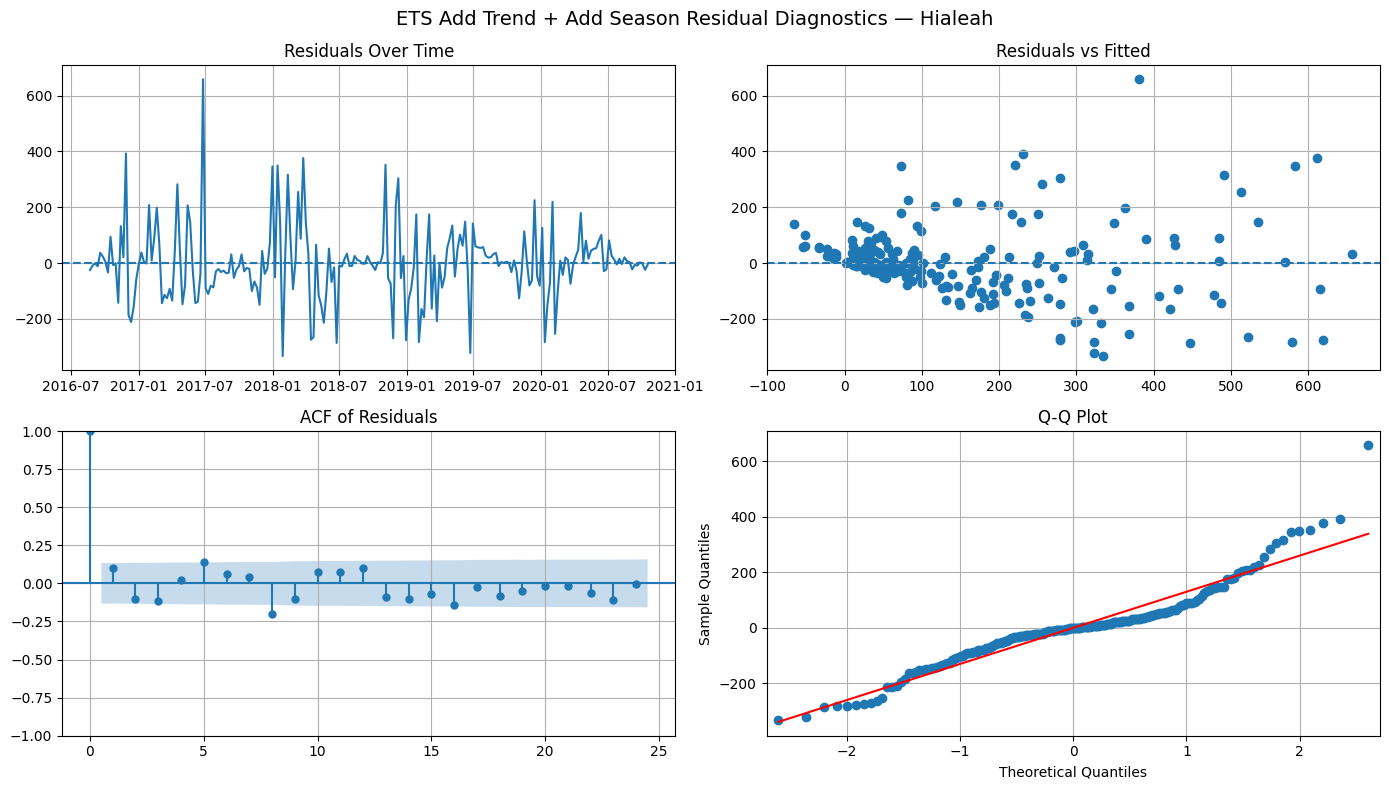

Ljung-Box Test:


,lb_stat,lb_pvalue
10,26.315681,0.003338
20,42.882880,0.002118


,lb_stat,lb_pvalue
10,26.315681,0.003338
20,42.882880,0.002118
30,62.519214,0.000451


In [39]:
# ============================================================
# 33. Best Overall ETS Residual Diagnostics
# ============================================================

residual_diagnostics(
    best_overall_ets_model.resid,
    fitted_values=best_overall_ets_model.fittedvalues,
    title=f"{best_overall_ets_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_overall_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [40]:
# ============================================================
# 34. Add Best ETS to Master Table
# ============================================================

add_result(
    best_overall_ets_name,
    test_series,
    best_overall_ets_forecast
)

{'RMSE': 466.00244509234,
 'MAE': 298.1466306360754,
 'R2': -0.13651575283730155,
 'nRMSE': 1.134478332156458,
 'MAPE': 78.30692259487296,
 'SMAPE': 114.87587766149765}

In [49]:
# ============================================================
# 35. Structural State Space Model Variations
# Research Question:
# Can interpretable decomposition into trend and seasonality
# explain mosquito abundance?
# ============================================================

structural_results = []
structural_fits = {}
structural_forecasts = {}

structural_configs = [
    {"level": "local level", "seasonal": None, "name": "Local Level"},
    {"level": "local linear trend", "seasonal": None, "name": "Local Linear Trend"},
    {"level": "local level", "seasonal": 52, "name": "Local Level + Seasonal"},
    {"level": "local linear trend", "seasonal": 52, "name": "Local Linear Trend + Seasonal"},
]

for config in structural_configs:
    try:
        model = UnobservedComponents(
            train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        structural_results.append({
            "Model": config["name"],
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        structural_fits[config["name"]] = fitted
        structural_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

structural_results_df = pd.DataFrame(structural_results).sort_values("RMSE").reset_index(drop=True)
structural_results_df

Local Level {'RMSE': 587.8762242198104, 'MAE': 393.8600617304825, 'R2': -0.8087180022773579, 'nRMSE': 1.4311788390620386, 'MAPE': 82.70938883149267, 'SMAPE': 151.78838633859422}
Local Linear Trend {'RMSE': 587.9762589296939, 'MAE': 394.0219081926925, 'R2': -0.809333607968959, 'nRMSE': 1.4314223725714044, 'MAPE': 82.85324451799235, 'SMAPE': 152.1459405120844}
Local Level + Seasonal {'RMSE': 474.62768865968803, 'MAE': 303.7544511183524, 'R2': -0.17897666546178526, 'nRMSE': 1.1554764021017547, 'MAPE': 75.23551894543772, 'SMAPE': 108.08012685539423}
Local Linear Trend + Seasonal {'RMSE': 476.01887693839046, 'MAE': 305.69033455096013, 'R2': -0.1858982266472229, 'nRMSE': 1.1588632361726043, 'MAPE': 77.36632199515059, 'SMAPE': 113.51050522972936}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626
1,Local Linear Trend + Seasonal,local linear trend,52.0,476.018877,305.690335,-0.185898,1.158863,77.366322,113.510505,2200.873011,2213.296793
2,Local Level,local level,NaN,587.876224,393.860062,-0.808718,1.431179,82.709389,151.788386,2831.095514,2837.855309
3,Local Linear Trend,local linear trend,NaN,587.976259,394.021908,-0.809334,1.431422,82.853245,152.145941,2828.828273,2838.954109


In [50]:
# ============================================================
# 36. Log-Structural State Space Variations
# ============================================================

log_structural_results = []
log_structural_fits = {}
log_structural_forecasts = {}

log_train_series = np.log1p(train_series)

for config in structural_configs:
    try:
        model = UnobservedComponents(
            log_train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        log_forecast = fitted.forecast(steps=len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        model_name = "Log-" + config["name"]

        log_structural_results.append({
            "Model": model_name,
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_structural_fits[model_name] = fitted
        log_structural_forecasts[model_name] = forecast_original

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_structural_results_df = pd.DataFrame(log_structural_results).sort_values("RMSE").reset_index(drop=True)
log_structural_results_df

Log-Local Level {'RMSE': 589.288674057716, 'MAE': 395.77130695030417, 'R2': -0.8174198084503654, 'nRMSE': 1.4346174341879594, 'MAPE': 84.09388430580591, 'SMAPE': 155.45127774612732}
Log-Local Linear Trend {'RMSE': 597.967341703569, 'MAE': 408.44308630417106, 'R2': -0.871345597046097, 'nRMSE': 1.455745564522676, 'MAPE': 97.79396002132523, 'SMAPE': 193.24776258014396}
Log-Local Level + Seasonal {'RMSE': 524.4394436446637, 'MAE': 338.9407218780455, 'R2': -0.439427398265674, 'nRMSE': 1.2767426257284218, 'MAPE': 75.65184868673518, 'SMAPE': 121.30709106832376}
Log-Local Linear Trend + Seasonal {'RMSE': 528.6849286626003, 'MAE': 343.1884026497382, 'R2': -0.4628268695841935, 'nRMSE': 1.2870782169105444, 'MAPE': 76.89040225403852, 'SMAPE': 124.75552679433012}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Level + Seasonal,local level,52.0,524.439444,338.940722,-0.439427,1.276743,75.651849,121.307091,612.318899,621.654863
1,Log-Local Linear Trend + Seasonal,local linear trend,52.0,528.684929,343.188403,-0.462827,1.287078,76.890402,124.755527,614.276122,626.699904
2,Log-Local Level,local level,NaN,589.288674,395.771307,-0.817420,1.434617,84.093884,155.451278,725.316947,732.076742
3,Log-Local Linear Trend,local linear trend,NaN,597.967342,408.443086,-0.871346,1.455746,97.793960,193.247763,734.985464,745.111299


In [51]:
# ============================================================
# 37. Combined Structural Results
# ============================================================

all_structural_results_df = pd.concat(
    [structural_results_df, log_structural_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_structural_results_df

,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626
1,Local Linear Trend + Seasonal,local linear trend,52.0,476.018877,305.690335,-0.185898,1.158863,77.366322,113.510505,2200.873011,2213.296793
2,Log-Local Level + Seasonal,local level,52.0,524.439444,338.940722,-0.439427,1.276743,75.651849,121.307091,612.318899,621.654863
3,Log-Local Linear Trend + Seasonal,local linear trend,52.0,528.684929,343.188403,-0.462827,1.287078,76.890402,124.755527,614.276122,626.699904
4,Local Level,local level,NaN,587.876224,393.860062,-0.808718,1.431179,82.709389,151.788386,2831.095514,2837.855309
5,Local Linear Trend,local linear trend,NaN,587.976259,394.021908,-0.809334,1.431422,82.853245,152.145941,2828.828273,2838.954109
6,Log-Local Level,local level,NaN,589.288674,395.771307,-0.817420,1.434617,84.093884,155.451278,725.316947,732.076742
7,Log-Local Linear Trend,local linear trend,NaN,597.967342,408.443086,-0.871346,1.455746,97.793960,193.247763,734.985464,745.111299


In [52]:
# ============================================================
# 38. Best Structural Model
# ============================================================

best_structural_name = all_structural_results_df.iloc[0]["Model"]

if best_structural_name.startswith("Log-"):
    best_structural_model = log_structural_fits[best_structural_name]
    best_structural_forecast = log_structural_forecasts[best_structural_name]
else:
    best_structural_model = structural_fits[best_structural_name]
    best_structural_forecast = structural_forecasts[best_structural_name]

print("Best Structural Model:", best_structural_name)
display(all_structural_results_df.iloc[[0]])

Best Structural Model: Local Level + Seasonal


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626


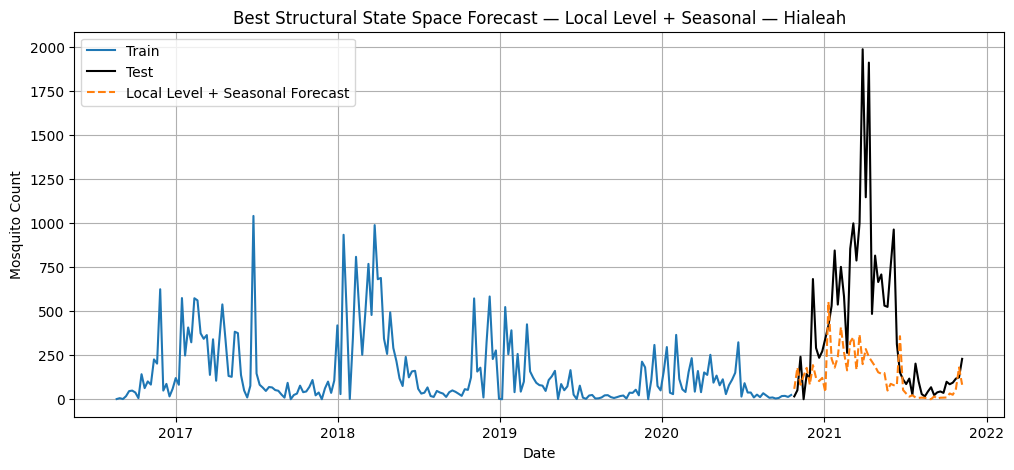

In [53]:
# ============================================================
# 39. Best Structural Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_structural_forecast.index,
    best_structural_forecast,
    label=f"{best_structural_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Structural State Space Forecast — {best_structural_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

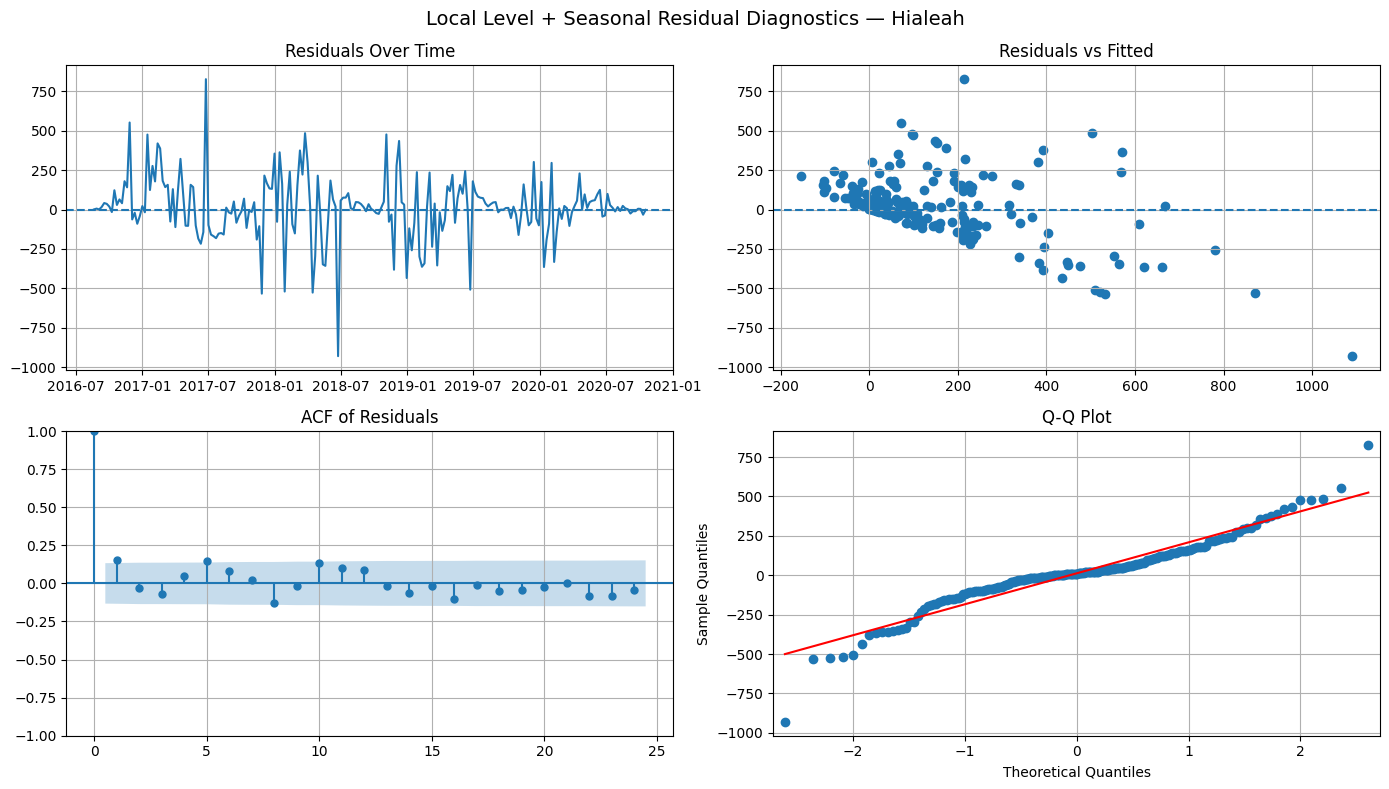

Ljung-Box Test:


,lb_stat,lb_pvalue
10,21.639607,0.017050
20,30.735879,0.058775


,lb_stat,lb_pvalue
10,21.639607,0.017050
20,30.735879,0.058775
30,47.557277,0.021937


{'RMSE': 474.62768865968803,
 'MAE': 303.7544511183524,
 'R2': -0.17897666546178526,
 'nRMSE': 1.1554764021017547,
 'MAPE': 75.23551894543772,
 'SMAPE': 108.08012685539423}

In [54]:
# ============================================================
# 40. Best Structural Residual Diagnostics
# ============================================================

residual_diagnostics(
    best_structural_model.resid,
    fitted_values=best_structural_model.fittedvalues,
    title=f"{best_structural_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_structural_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

add_result(
    best_structural_name,
    test_series,
    best_structural_forecast
)

In [55]:
# ============================================================
# 41. Prophet Models
# Research Question:
# Can Prophet's flexible additive decomposition capture mosquito
# trend and seasonal structure better than classical models?
# ============================================================

def prepare_prophet_df(ts):
    df = ts.reset_index()
    df.columns = ["ds", "y"]
    return df

prophet_df = prepare_prophet_df(ts_series)

train_prophet = prophet_df.iloc[:train_size].copy()
test_prophet = prophet_df.iloc[train_size:].copy()

train_prophet.head()

,ds,y
0,2016-08-21,1
1,2016-08-28,6
2,2016-09-04,1
3,2016-09-11,17
4,2016-09-18,46


In [56]:
# ============================================================
# 42. Prophet Hyperparameter Variations
# ============================================================

prophet_configs = [
    {
        "name": "Prophet Default",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Flexible Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.5,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Conservative Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Multiplicative Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Strong Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 20.0
    },
]

In [57]:
# ============================================================
# 43. Fit Prophet Variations
# ============================================================

prophet_results = []
prophet_models = {}
prophet_forecasts = {}

for config in prophet_configs:
    try:
        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast = np.maximum(test_forecast, 0)

        metrics = compute_metrics(test_series.values, test_forecast)

        prophet_results.append({
            "Model": config["name"],
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        prophet_models[config["name"]] = model
        prophet_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

prophet_results_df = pd.DataFrame(prophet_results).sort_values("RMSE").reset_index(drop=True)
prophet_results_df

12:27:46 - cmdstanpy - INFO - Chain [1] start processing
12:27:46 - cmdstanpy - INFO - Chain [1] done processing
12:27:46 - cmdstanpy - INFO - Chain [1] start processing
12:27:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Default {'RMSE': 509.4103146467173, 'MAE': 334.6407471791358, 'R2': -0.3581087199225792, 'nRMSE': 1.2401543601969482, 'MAPE': 79.59756082982523, 'SMAPE': 145.07524721139544}


12:27:47 - cmdstanpy - INFO - Chain [1] start processing
12:27:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Flexible Trend {'RMSE': 474.166824338575, 'MAE': 297.8834905799941, 'R2': -0.17668820021863252, 'nRMSE': 1.1543544324814814, 'MAPE': 67.68154233198285, 'SMAPE': 106.61042346760622}


12:27:47 - cmdstanpy - INFO - Chain [1] start processing
12:27:47 - cmdstanpy - INFO - Chain [1] done processing


...

12:27:47 - cmdstanpy - INFO - Chain [1] start processing


Prophet Multiplicative Seasonality {'RMSE': 583.7138126050689, 'MAE': 395.8115812822553, 'R2': -0.7831957049715386, 'nRMSE': 1.4210454892563205, 'MAPE': 94.36013757519187, 'SMAPE': 181.7902531887914}


12:27:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Strong Seasonality {'RMSE': 509.7771370209114, 'MAE': 335.03764263117336, 'R2': -0.3600653510317755, 'nRMSE': 1.2410473856298747, 'MAPE': 79.81344214834891, 'SMAPE': 145.4437138299039}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.50,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423
1,Prophet Conservative Trend,additive,0.01,10.0,494.983463,319.823467,-0.282273,1.205032,76.809147,134.970971
2,Prophet Default,additive,0.05,10.0,509.410315,334.640747,-0.358109,1.240154,79.597561,145.075247
3,Prophet Strong Seasonality,additive,0.05,20.0,509.777137,335.037643,-0.360065,1.241047,79.813442,145.443714
4,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,583.713813,395.811581,-0.783196,1.421045,94.360138,181.790253


Best Prophet model: Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.5,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423


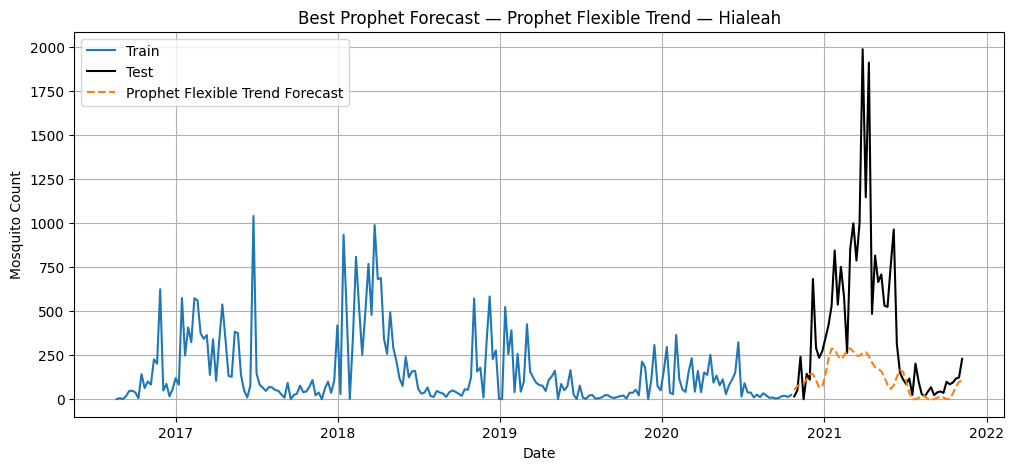

In [58]:
# ============================================================
# 44. Best Prophet Forecast Plot
# ============================================================

best_prophet_name = prophet_results_df.iloc[0]["Model"]
best_prophet_model = prophet_models[best_prophet_name]
best_prophet_forecast = prophet_forecasts[best_prophet_name]

print("Best Prophet model:", best_prophet_name)
display(prophet_results_df.iloc[[0]])

best_prophet_test_forecast = best_prophet_forecast.iloc[train_size:]["yhat"].values
best_prophet_test_forecast = np.maximum(best_prophet_test_forecast, 0)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_prophet_test_forecast,
    label=f"{best_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Prophet Forecast — {best_prophet_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

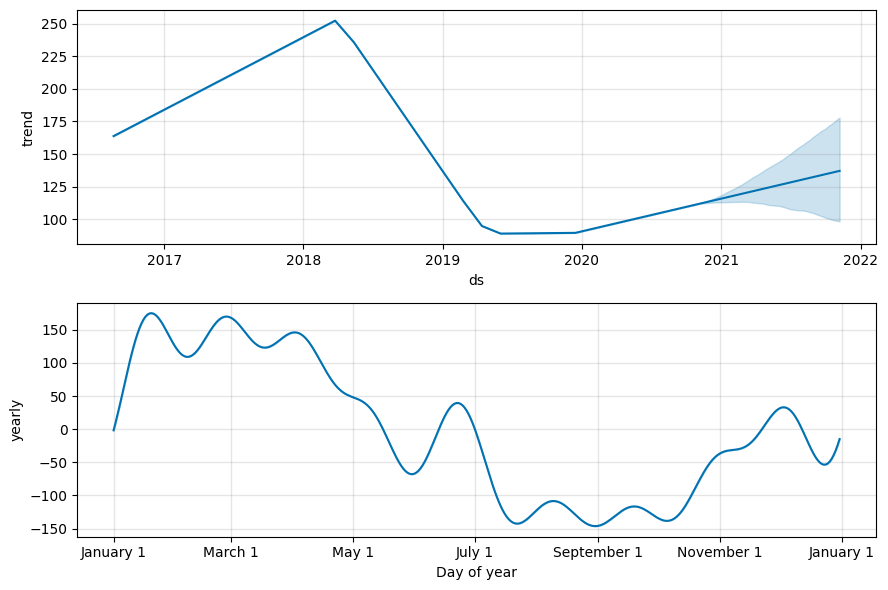

In [59]:
# ============================================================
# 45. Prophet Component Decomposition
# ============================================================

best_prophet_model.plot_components(best_prophet_forecast)
plt.show()

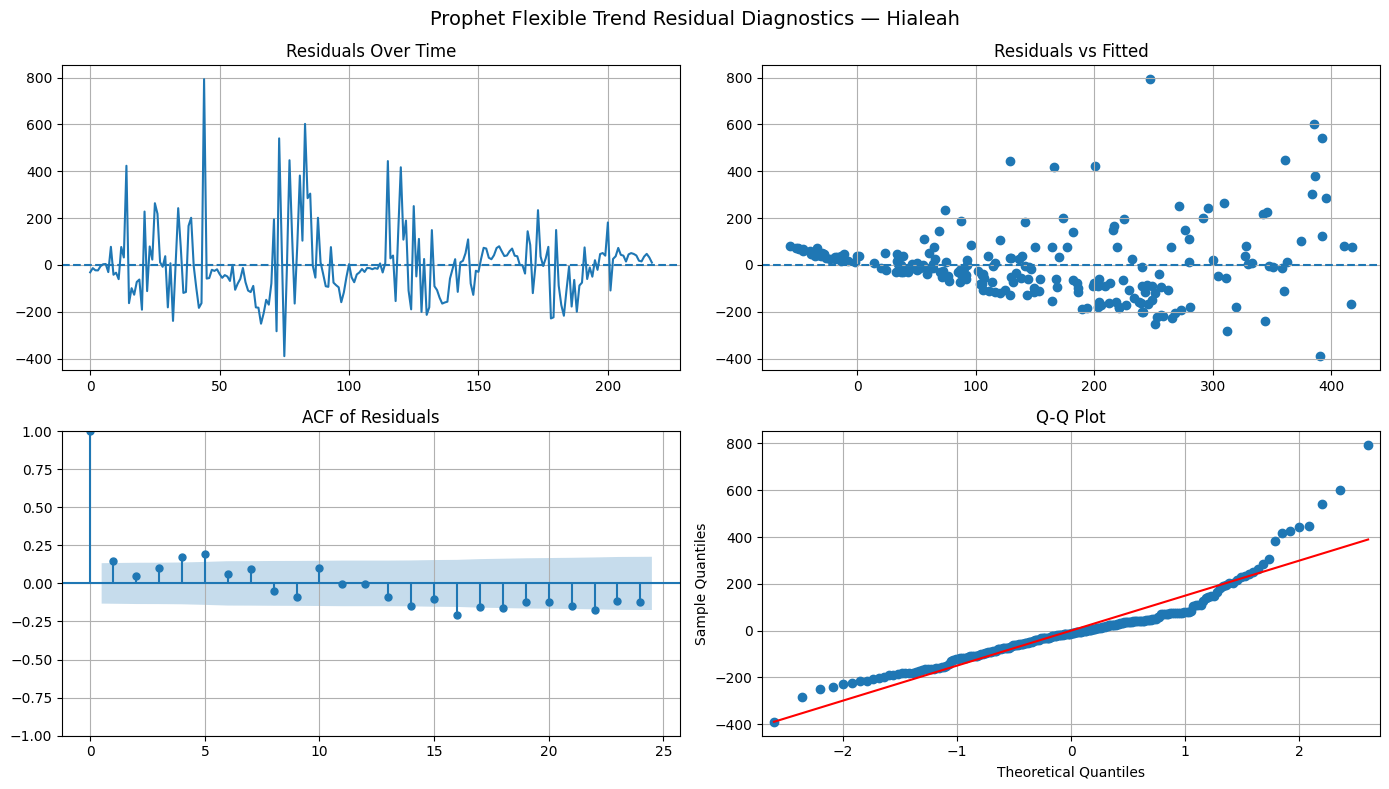

Ljung-Box Test:


,lb_stat,lb_pvalue
10,30.660900,6.673404e-04
20,69.911173,1.883206e-07


,lb_stat,lb_pvalue
10,30.660900,6.673404e-04
20,69.911173,1.883206e-07
30,101.866289,9.398467e-10


In [60]:
# ============================================================
# 46. Prophet Residual Diagnostics
# ============================================================

prophet_train_forecast = best_prophet_forecast.iloc[:train_size]

prophet_train_residuals = (
    train_prophet["y"].values - prophet_train_forecast["yhat"].values
)

residual_diagnostics(
    prophet_train_residuals,
    fitted_values=prophet_train_forecast["yhat"].values,
    title=f"{best_prophet_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(prophet_train_residuals).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [61]:
# ============================================================
# 47. Log-Prophet Models
# ============================================================

log_prophet_df = prophet_df.copy()
log_prophet_df["y"] = np.log1p(log_prophet_df["y"])

log_train_prophet = log_prophet_df.iloc[:train_size].copy()

log_prophet_results = []
log_prophet_models = {}
log_prophet_forecasts = {}

for config in prophet_configs:
    try:
        model_name = "Log-" + config["name"]

        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(log_train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        log_test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast_original = np.expm1(log_test_forecast)
        test_forecast_original = np.maximum(test_forecast_original, 0)

        metrics = compute_metrics(test_series.values, test_forecast_original)

        log_prophet_results.append({
            "Model": model_name,
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_prophet_models[model_name] = model
        log_prophet_forecasts[model_name] = forecast

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_prophet_results_df = pd.DataFrame(log_prophet_results).sort_values("RMSE").reset_index(drop=True)
log_prophet_results_df

12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:28 - cmdstanpy - INFO - Chain [1] done processing
12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:28 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Default {'RMSE': 541.5601481858081, 'MAE': 358.45867722594363, 'R2': -0.5349437530056624, 'nRMSE': 1.3184228111818097, 'MAPE': 80.83791915555506, 'SMAPE': 136.36064211443508}


12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:28 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Flexible Trend {'RMSE': 507.6000417716627, 'MAE': 326.1624089737598, 'R2': -0.3484733478801656, 'nRMSE': 1.235747268831509, 'MAPE': 70.60891120259633, 'SMAPE': 107.5745159306924}


12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:29 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Conservative Trend {'RMSE': 543.3779067384697, 'MAE': 360.34002172314393, 'R2': -0.5452651910071433, 'nRMSE': 1.3228481263551628, 'MAPE': 81.3521576257584, 'SMAPE': 138.4892598397364}


12:28:29 - cmdstanpy - INFO - Chain [1] start processing
12:28:29 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Multiplicative Seasonality {'RMSE': 551.1448937920471, 'MAE': 365.3828099215699, 'R2': -0.5897566310950773, 'nRMSE': 1.3417567793273102, 'MAPE': 80.8807012222501, 'SMAPE': 138.01226730110866}
Log-Prophet Strong Seasonality {'RMSE': 541.695712856471, 'MAE': 358.5987933111241, 'R2': -0.5357123109917967, 'nRMSE': 1.318752842028413, 'MAPE': 80.8920087710242, 'SMAPE': 136.54365765549448}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.50,10.0,507.600042,326.162409,-0.348473,1.235747,70.608911,107.574516
1,Log-Prophet Default,additive,0.05,10.0,541.560148,358.458677,-0.534944,1.318423,80.837919,136.360642
2,Log-Prophet Strong Seasonality,additive,0.05,20.0,541.695713,358.598793,-0.535712,1.318753,80.892009,136.543658
3,Log-Prophet Conservative Trend,additive,0.01,10.0,543.377907,360.340022,-0.545265,1.322848,81.352158,138.489260
4,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,551.144894,365.382810,-0.589757,1.341757,80.880701,138.012267


In [62]:
# ============================================================
# 48. Combined Prophet Results and Best Overall Prophet
# ============================================================

all_prophet_results_df = pd.concat(
    [prophet_results_df, log_prophet_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_prophet_results_df)

best_overall_prophet_name = all_prophet_results_df.iloc[0]["Model"]

if best_overall_prophet_name.startswith("Log-"):
    best_overall_prophet_model = log_prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = log_prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = True
else:
    best_overall_prophet_model = prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = False

print("Best overall Prophet model:", best_overall_prophet_name)
display(all_prophet_results_df.iloc[[0]])

,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.50,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423
1,Prophet Conservative Trend,additive,0.01,10.0,494.983463,319.823467,-0.282273,1.205032,76.809147,134.970971
2,Log-Prophet Flexible Trend,additive,0.50,10.0,507.600042,326.162409,-0.348473,1.235747,70.608911,107.574516
3,Prophet Default,additive,0.05,10.0,509.410315,334.640747,-0.358109,1.240154,79.597561,145.075247
4,Prophet Strong Seasonality,additive,0.05,20.0,509.777137,335.037643,-0.360065,1.241047,79.813442,145.443714
5,Log-Prophet Default,additive,0.05,10.0,541.560148,358.458677,-0.534944,1.318423,80.837919,136.360642
6,Log-Prophet Strong Seasonality,additive,0.05,20.0,541.695713,358.598793,-0.535712,1.318753,80.892009,136.543658
7,Log-Prophet Conservative Trend,additive,0.01,10.0,543.377907,360.340022,-0.545265,1.322848,81.352158,138.489260
8,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,551.144894,365.382810,-0.589757,1.341757,80.880701,138.012267
9,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,583.713813,395.811581,-0.783196,1.421045,94.360138,181.790253


Best overall Prophet model: Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.5,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423


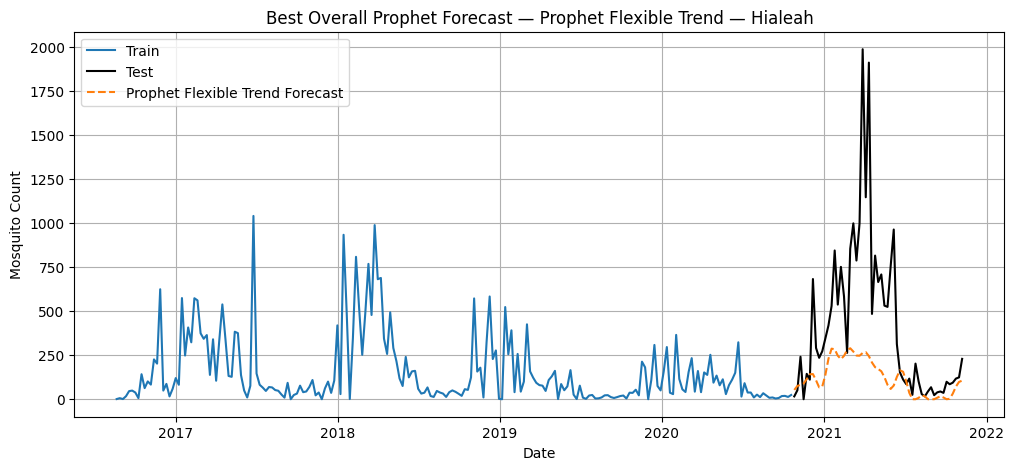

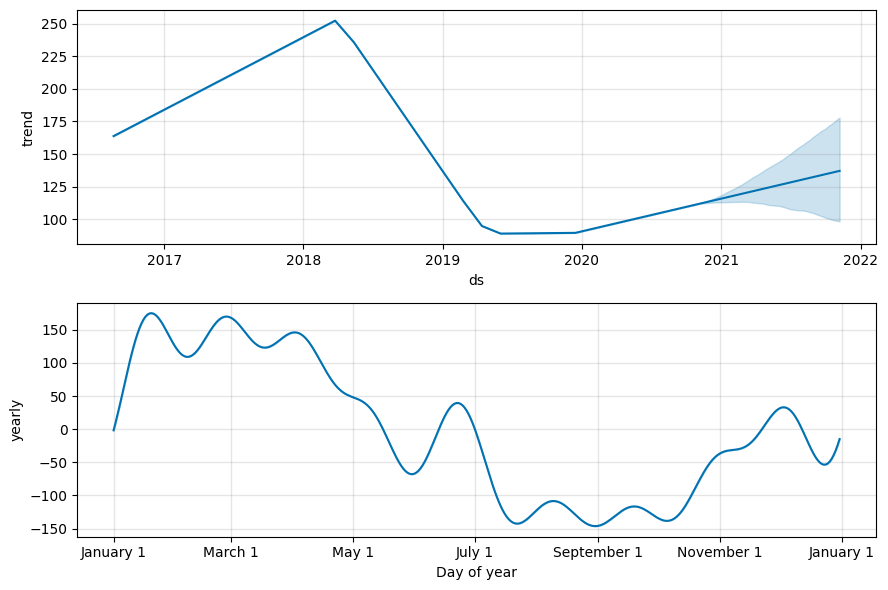

{'RMSE': 474.166824338575,
 'MAE': 297.8834905799941,
 'R2': -0.17668820021863252,
 'nRMSE': 1.1543544324814814,
 'MAPE': 67.68154233198285,
 'SMAPE': 106.61042346760622}

In [63]:
# ============================================================
# 49. Best Overall Prophet Forecast Plot
# ============================================================

if is_log_prophet:
    best_overall_prophet_test_forecast = np.expm1(
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )
else:
    best_overall_prophet_test_forecast = (
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )

best_overall_prophet_test_forecast = np.maximum(
    best_overall_prophet_test_forecast,
    0
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_overall_prophet_test_forecast,
    label=f"{best_overall_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall Prophet Forecast — {best_overall_prophet_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

best_overall_prophet_model.plot_components(best_overall_prophet_forecast)
plt.show()

add_result(
    best_overall_prophet_name,
    test_series.values,
    best_overall_prophet_test_forecast
)

In [64]:
# ============================================================
# 50. LSTM Model
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)

def create_lstm_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [65]:
# ============================================================
# 51. Fit and Evaluate One LSTM
# ============================================================

def fit_evaluate_lstm(train_series, test_series, lookback=12, units=64, dropout=0.2, epochs=150):
    scaler = MinMaxScaler()

    train_values = train_series.values.reshape(-1, 1)
    test_values = test_series.values.reshape(-1, 1)

    scaled_train = scaler.fit_transform(train_values)

    combined_values = np.concatenate([train_values[-lookback:], test_values])
    scaled_combined = scaler.transform(combined_values)

    X_train, y_train = create_lstm_sequences(scaled_train, lookback)
    X_test, y_test = create_lstm_sequences(scaled_combined, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = Sequential([
        LSTM(units, activation="tanh", input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    y_pred = scaler.inverse_transform(pred_scaled).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_true, y_pred)

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "lookback": lookback,
        "units": units,
        "dropout": dropout,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": metrics
    }

In [66]:
# ============================================================
# 52. LSTM Variations
# ============================================================

lstm_configs = [
    {"name": "LSTM Lookback 4", "lookback": 4, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 8", "lookback": 8, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 12", "lookback": 12, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 16", "lookback": 16, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 24", "lookback": 24, "units": 64, "dropout": 0.3},
]

lstm_results = []
lstm_outputs = {}

for config in lstm_configs:
    print("Fitting:", config["name"])

    try:
        output = fit_evaluate_lstm(
            train_series=train_series,
            test_series=test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        metrics = output["metrics"]

        lstm_results.append({
            "Model": config["name"],
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        lstm_outputs[config["name"]] = output

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

lstm_results_df = pd.DataFrame(lstm_results).sort_values("RMSE").reset_index(drop=True)
lstm_results_df

Fitting: LSTM Lookback 4
LSTM Lookback 4 {'RMSE': 318.6471609572451, 'MAE': 194.3639469493519, 'R2': 0.4686029052773686, 'nRMSE': 0.7757433539592989, 'MAPE': 82.15025796346578, 'SMAPE': 56.603220471797236}
Fitting: LSTM Lookback 8
LSTM Lookback 8 {'RMSE': 326.354070494251, 'MAE': 206.06201629638673, 'R2': 0.44258694421131606, 'nRMSE': 0.7945057488130226, 'MAPE': 96.48052002340717, 'SMAPE': 60.77710120340045}
Fitting: LSTM Lookback 12
LSTM Lookback 12 {'RMSE': 429.02926031259256, 'MAE': 266.8305385242809, 'R2': 0.03667486042983692, 'nRMSE': 1.0444674803998137, 'MAPE': 102.4932207062849, 'SMAPE': 78.64437808791196}
Fitting: LSTM Lookback 16
LSTM Lookback 16 {'RMSE': 363.31315488769235, 'MAE': 225.10144681063565, 'R2': 0.3091857061029757, 'nRMSE': 0.8844822733190103, 'MAPE': 102.02213549971559, 'SMAPE': 67.37007543836812}
Fitting: LSTM Lookback 24
LSTM Lookback 24 {'RMSE': 345.86189202414937, 'MAE': 209.96436850807885, 'R2': 0.3739565231057643, 'nRMSE': 0.8419973469072334, 'MAPE': 83.9035

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,318.647161,194.363947,0.468603,0.775743,82.150258,56.603220
1,LSTM Lookback 8,8,32,0.2,326.354070,206.062016,0.442587,0.794506,96.480520,60.777101
2,LSTM Lookback 24,24,64,0.3,345.861892,209.964369,0.373957,0.841997,83.903591,60.723812
3,LSTM Lookback 16,16,64,0.2,363.313155,225.101447,0.309186,0.884482,102.022135,67.370075
4,LSTM Lookback 12,12,64,0.2,429.029260,266.830539,0.036675,1.044467,102.493221,78.644378


Best LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,318.647161,194.363947,0.468603,0.775743,82.150258,56.60322


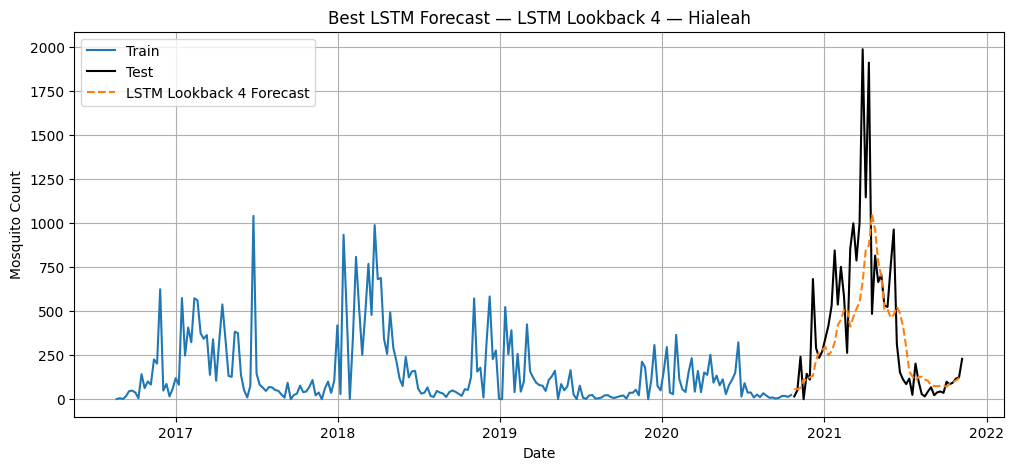

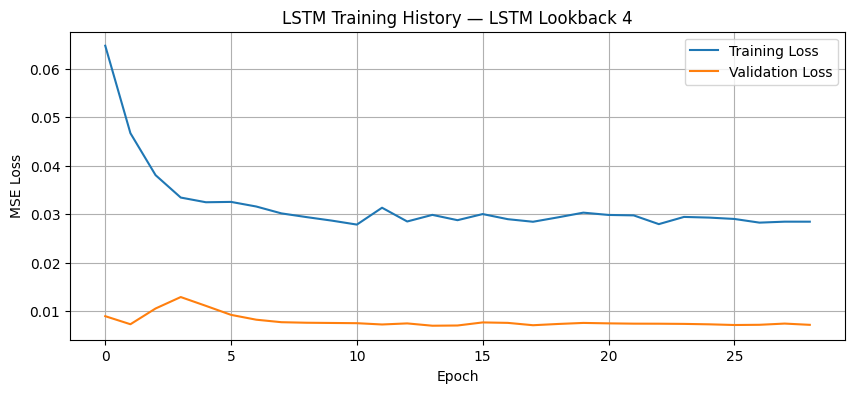

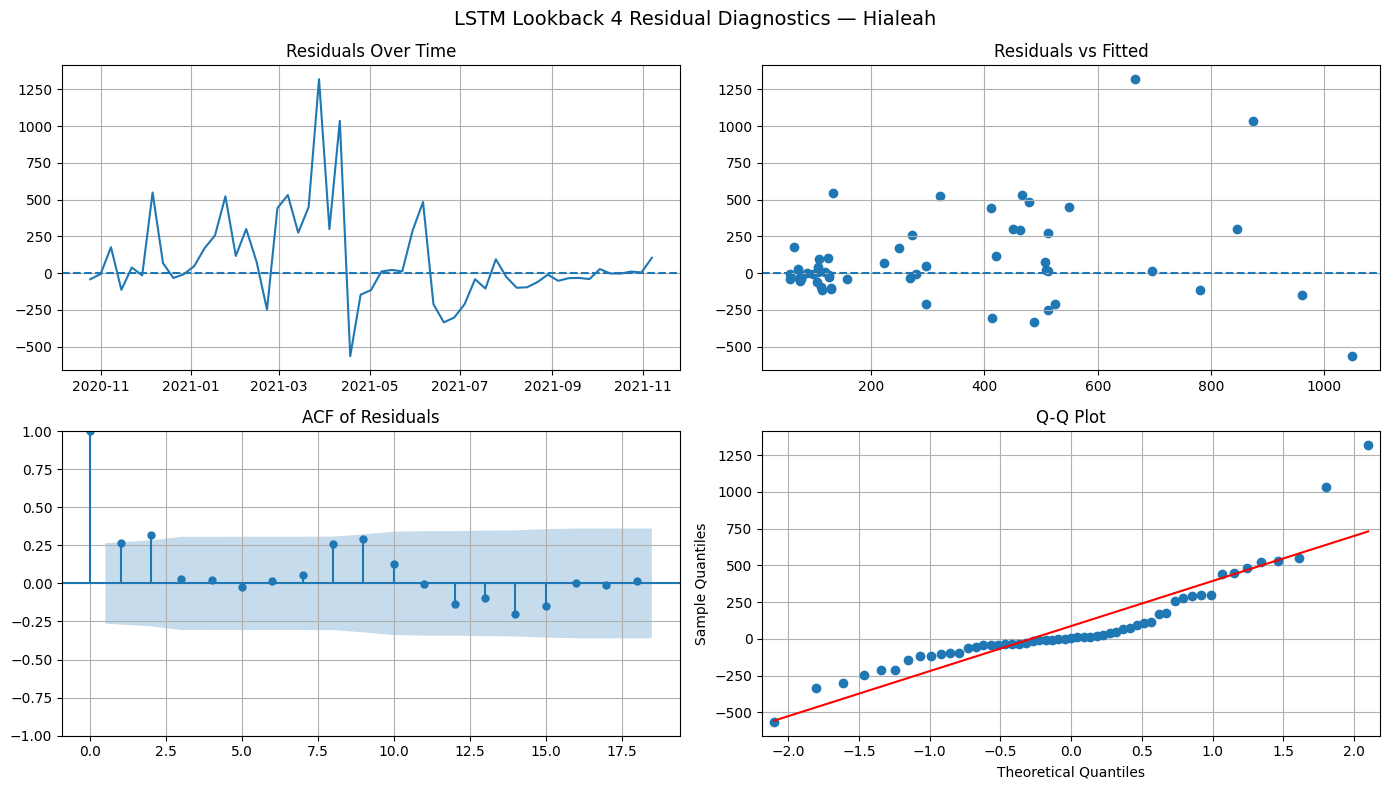

Ljung-Box Test:


,lb_stat,lb_pvalue
10,21.574478,0.017425
20,31.760416,0.045919


{'RMSE': 318.6471609572451,
 'MAE': 194.3639469493519,
 'R2': 0.4686029052773686,
 'nRMSE': 0.7757433539592989,
 'MAPE': 82.15025796346578,
 'SMAPE': 56.603220471797236}

In [67]:
# ============================================================
# 53. Best LSTM Forecast and Diagnostics
# ============================================================

best_lstm_name = lstm_results_df.iloc[0]["Model"]
best_lstm_output = lstm_outputs[best_lstm_name]

print("Best LSTM model:", best_lstm_name)
display(lstm_results_df.iloc[[0]])

lstm_test_index = test_series.index

best_lstm_true = pd.Series(
    best_lstm_output["y_true"],
    index=lstm_test_index,
    name="Observed"
)

best_lstm_pred = pd.Series(
    best_lstm_output["y_pred"],
    index=lstm_test_index,
    name="LSTM Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(best_lstm_true.index, best_lstm_true, label="Test", color="black")
plt.plot(
    best_lstm_pred.index,
    best_lstm_pred,
    label=f"{best_lstm_name} Forecast",
    linestyle="--"
)

plt.title(f"Best LSTM Forecast — {best_lstm_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

history = best_lstm_output["history"]

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"LSTM Training History — {best_lstm_name}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

lstm_residuals = best_lstm_true - best_lstm_pred

residual_diagnostics(
    lstm_residuals,
    fitted_values=best_lstm_pred,
    title=f"{best_lstm_name} Residual Diagnostics — Hialeah"
)

add_result(
    best_lstm_name,
    best_lstm_true.values,
    best_lstm_pred.values
)

In [68]:
# ============================================================
# 54.  Log-LSTM
# ============================================================

log_train_series = np.log1p(train_series)
log_test_series = np.log1p(test_series)

log_lstm_results = []
log_lstm_outputs = {}

for config in lstm_configs:
    model_name = "Log-" + config["name"]
    print("Fitting:", model_name)

    try:
        output = fit_evaluate_lstm(
            train_series=log_train_series,
            test_series=log_test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        y_true_original = np.expm1(output["y_true"])
        y_pred_original = np.expm1(output["y_pred"])
        y_pred_original = np.maximum(y_pred_original, 0)

        metrics = compute_metrics(y_true_original, y_pred_original)

        output["y_true_original"] = y_true_original
        output["y_pred_original"] = y_pred_original
        output["metrics_original"] = metrics

        log_lstm_results.append({
            "Model": model_name,
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_lstm_outputs[model_name] = output

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_lstm_results_df = pd.DataFrame(log_lstm_results).sort_values("RMSE").reset_index(drop=True)
log_lstm_results_df

Fitting: Log-LSTM Lookback 4
Log-LSTM Lookback 4 {'RMSE': 457.955401350395, 'MAE': 283.12355298129, 'R2': -0.09760339125251094, 'nRMSE': 1.1148878839532455, 'MAPE': 64.89344289498301, 'SMAPE': 82.81203428930995}
Fitting: Log-LSTM Lookback 8
Log-LSTM Lookback 8 {'RMSE': 452.4827714804558, 'MAE': 281.53481514670636, 'R2': -0.07152711316300464, 'nRMSE': 1.1015648207960813, 'MAPE': 69.65357510809754, 'SMAPE': 85.76782818968147}
Fitting: Log-LSTM Lookback 12
Log-LSTM Lookback 12 {'RMSE': 435.5762836323182, 'MAE': 263.92272193215115, 'R2': 0.007049682143002167, 'nRMSE': 1.0604061437578567, 'MAPE': 61.44601629023065, 'SMAPE': 76.53045297301436}
Fitting: Log-LSTM Lookback 16
Log-LSTM Lookback 16 {'RMSE': 445.4082934690854, 'MAE': 271.2191037958319, 'R2': -0.038282818750272396, 'nRMSE': 1.0843420742209495, 'MAPE': 61.47493434940239, 'SMAPE': 79.09740060106554}
Fitting: Log-LSTM Lookback 24
Log-LSTM Lookback 24 {'RMSE': 439.3820419593466, 'MAE': 270.15365087335766, 'R2': -0.010377518973836208, '

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-LSTM Lookback 12,12,64,0.2,435.576284,263.922722,0.007050,1.060406,61.446016,76.530453
1,Log-LSTM Lookback 24,24,64,0.3,439.382042,270.153651,-0.010378,1.069671,60.685662,84.000633
2,Log-LSTM Lookback 16,16,64,0.2,445.408293,271.219104,-0.038283,1.084342,61.474934,79.097401
3,Log-LSTM Lookback 8,8,32,0.2,452.482771,281.534815,-0.071527,1.101565,69.653575,85.767828
4,Log-LSTM Lookback 4,4,32,0.2,457.955401,283.123553,-0.097603,1.114888,64.893443,82.812034


In [69]:
# ============================================================
# 55. Best Overall LSTM or Log-LSTM
# ============================================================

all_lstm_results_df = pd.concat(
    [lstm_results_df, log_lstm_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_lstm_results_df)

best_overall_lstm_name = all_lstm_results_df.iloc[0]["Model"]

if best_overall_lstm_name.startswith("Log-"):
    best_overall_lstm_output = log_lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true_original"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred_original"],
        index=test_series.index
    )
else:
    best_overall_lstm_output = lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred"],
        index=test_series.index
    )

print("Best overall LSTM model:", best_overall_lstm_name)
display(all_lstm_results_df.iloc[[0]])

add_result(
    best_overall_lstm_name,
    best_overall_lstm_true.values,
    best_overall_lstm_pred.values
)

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,318.647161,194.363947,0.468603,0.775743,82.150258,56.603220
1,LSTM Lookback 8,8,32,0.2,326.354070,206.062016,0.442587,0.794506,96.480520,60.777101
2,LSTM Lookback 24,24,64,0.3,345.861892,209.964369,0.373957,0.841997,83.903591,60.723812
3,LSTM Lookback 16,16,64,0.2,363.313155,225.101447,0.309186,0.884482,102.022135,67.370075
4,LSTM Lookback 12,12,64,0.2,429.029260,266.830539,0.036675,1.044467,102.493221,78.644378
5,Log-LSTM Lookback 12,12,64,0.2,435.576284,263.922722,0.007050,1.060406,61.446016,76.530453
6,Log-LSTM Lookback 24,24,64,0.3,439.382042,270.153651,-0.010378,1.069671,60.685662,84.000633
7,Log-LSTM Lookback 16,16,64,0.2,445.408293,271.219104,-0.038283,1.084342,61.474934,79.097401
8,Log-LSTM Lookback 8,8,32,0.2,452.482771,281.534815,-0.071527,1.101565,69.653575,85.767828
9,Log-LSTM Lookback 4,4,32,0.2,457.955401,283.123553,-0.097603,1.114888,64.893443,82.812034


Best overall LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,318.647161,194.363947,0.468603,0.775743,82.150258,56.60322


{'RMSE': 318.6471609572451,
 'MAE': 194.3639469493519,
 'R2': 0.4686029052773686,
 'nRMSE': 0.7757433539592989,
 'MAPE': 82.15025796346578,
 'SMAPE': 56.603220471797236}

In [70]:
# ============================================================
# 56. Final Hialeah Univariate Model Summary Table
# ============================================================

final_results_df = pd.DataFrame(model_results)

final_results_df = final_results_df.drop_duplicates(
    subset=["City", "Model"],
    keep="last"
)

final_results_df = final_results_df.sort_values("RMSE").reset_index(drop=True)

display(final_results_df)

final_results_df.to_csv("hialeah_univariate_final_model_summary.csv", index=False)

,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Rolling Mean,2.007223e+02,1.142376e+02,5.398545e-01,9.740377e-01,4.927544e+02,65.818080
1,Hialeah,"Rolling ARIMA(4, 0, 3)",2.080133e+02,1.307687e+02,5.058189e-01,1.009418e+00,5.736102e+02,79.457637
2,Hialeah,Naive,2.311755e+02,1.336697e+02,3.896380e-01,1.121817e+00,4.902418e+02,77.129786
3,Hialeah,"Rolling Log-ARIMA(4, 0, 3)",2.412847e+02,1.336438e+02,3.350891e-01,1.170873e+00,3.213775e+02,80.205972
4,Hialeah,LSTM Lookback 4,3.186472e+02,1.943639e+02,4.686029e-01,7.757434e-01,8.215026e+01,56.603220
5,Hialeah,Seasonal Naive,3.325025e+02,1.943394e+02,-2.626813e-01,1.613523e+00,6.100709e+02,101.633941
6,Hialeah,ETS Add Trend + Add Season,4.660024e+02,2.981466e+02,-1.365158e-01,1.134478e+00,7.830692e+01,114.875878
7,Hialeah,Prophet Flexible Trend,4.741668e+02,2.978835e+02,-1.766882e-01,1.154354e+00,6.768154e+01,106.610423
8,Hialeah,Local Level + Seasonal,4.746277e+02,3.037545e+02,-1.789767e-01,1.155476e+00,7.523552e+01,108.080127
9,Hialeah,"ARIMA(4, 0, 3)",5.097458e+02,3.289680e+02,-3.598983e-01,1.240971e+00,1.308402e+02,97.243661


In [71]:
final_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}"
})

,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Rolling Mean,200.72,114.24,0.540,0.974,492.75,65.82
1,Hialeah,"Rolling ARIMA(4, 0, 3)",208.01,130.77,0.506,1.009,573.61,79.46
2,Hialeah,Naive,231.18,133.67,0.390,1.122,490.24,77.13
3,Hialeah,"Rolling Log-ARIMA(4, 0, 3)",241.28,133.64,0.335,1.171,321.38,80.21
4,Hialeah,LSTM Lookback 4,318.65,194.36,0.469,0.776,82.15,56.60
5,Hialeah,Seasonal Naive,332.50,194.34,-0.263,1.614,610.07,101.63
6,Hialeah,ETS Add Trend + Add Season,466.00,298.15,-0.137,1.134,78.31,114.88
7,Hialeah,Prophet Flexible Trend,474.17,297.88,-0.177,1.154,67.68,106.61
8,Hialeah,Local Level + Seasonal,474.63,303.75,-0.179,1.155,75.24,108.08
9,Hialeah,"ARIMA(4, 0, 3)",509.75,328.97,-0.360,1.241,130.84,97.24


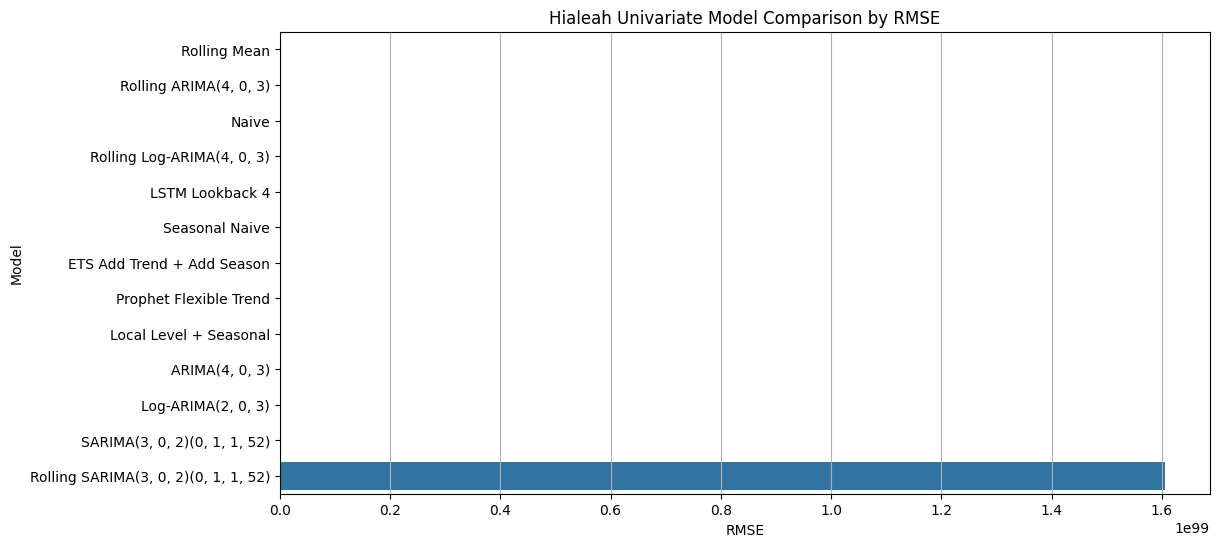

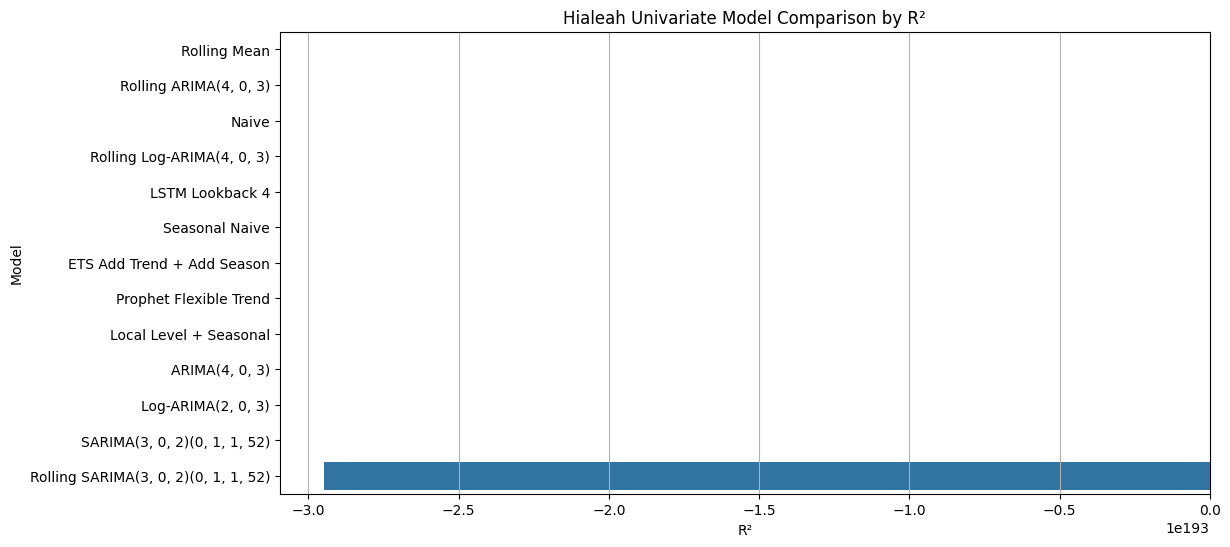

In [72]:
# ============================================================
# 57. Model Comparison Plots
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="RMSE",
    y="Model"
)

plt.title("Hialeah Univariate Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="R2",
    y="Model"
)

plt.title("Hialeah Univariate Model Comparison by R²")
plt.xlabel("R²")
plt.ylabel("Model")
plt.show()

In [73]:
# ============================================================
# 58. Peak / Outbreak Performance Analysis
# ============================================================

def compute_peak_metrics(y_true, y_pred, percentile=90):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = np.percentile(y_true, percentile)
    peak_mask = y_true >= threshold

    if peak_mask.sum() == 0:
        return {
            "Peak_Threshold": threshold,
            "Peak_RMSE": np.nan,
            "Peak_MAE": np.nan,
            "Peak_Count": 0
        }

    return {
        "Peak_Threshold": threshold,
        "Peak_RMSE": np.sqrt(mean_squared_error(y_true[peak_mask], y_pred[peak_mask])),
        "Peak_MAE": mean_absolute_error(y_true[peak_mask], y_pred[peak_mask]),
        "Peak_Count": peak_mask.sum()
    }


peak_results = []

peak_results.append({
    "Model": f"Rolling ARIMA{best_arima_order}",
    **compute_peak_metrics(y_true_roll_arima, y_pred_roll_arima)
})

peak_results.append({
    "Model": best_overall_ets_name,
    **compute_peak_metrics(test_series.values, best_overall_ets_forecast.values)
})

peak_results.append({
    "Model": best_overall_prophet_name,
    **compute_peak_metrics(test_series.values, best_overall_prophet_test_forecast)
})

peak_results.append({
    "Model": best_overall_lstm_name,
    **compute_peak_metrics(best_overall_lstm_true.values, best_overall_lstm_pred.values)
})

peak_results_df = pd.DataFrame(peak_results).sort_values("Peak_RMSE").reset_index(drop=True)

display(peak_results_df)

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 0, 3)",583.0,477.979238,402.640373,23
1,LSTM Lookback 4,919.4,777.126905,686.748993,6
2,ETS Add Trend + Add Season,919.4,1161.589354,1062.496628,6
3,Prophet Flexible Trend,919.4,1182.900552,1105.494849,6


In [74]:
peak_results_df.style.format({
    "Peak_Threshold": "{:.2f}",
    "Peak_RMSE": "{:.2f}",
    "Peak_MAE": "{:.2f}",
    "Peak_Count": "{:.0f}"
})

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 0, 3)",583.00,477.98,402.64,23
1,LSTM Lookback 4,919.40,777.13,686.75,6
2,ETS Add Trend + Add Season,919.40,1161.59,1062.50,6
3,Prophet Flexible Trend,919.40,1182.90,1105.49,6
